In [2]:
import pandas as pd
import numpy as np
import scipy as sp

import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import mpl_toolkits as mplot3d

import statsmodels.api as sm
from statsmodels.miscmodels.ordinal_model import OrderedModel
from scipy.stats.mstats import winsorize


pd.set_option("display.max_columns", None)
pd.reset_option("display.max_rows")
pd.set_option('future.no_silent_downcasting', True)

import sys
import os
sys.path.append(os.path.abspath("../../.."))
from utils.categorical_qcut import categorical_qcut

from tqdm import tqdm
tqdm.pandas()

### Helpers

In [3]:
from scipy.stats.mstats import winsorize

def winsorize_output(sample, variable, limits = [0, 0]):
    sample[f"nonwinsorised_{variable}"] = sample[variable]
    sample[f"winsorised_{variable}"] = winsorize(np.array(sample[f"nonwinsorised_{variable}"]), limits = limits, inclusive = [False, False])
    sample[[f"nonwinsorised_{variable}", f"winsorised_{variable}"]].describe()
    print(sample[[f"winsorised_{variable}", f"nonwinsorised_{variable}"]].describe())
    
    fig, axes = plt.subplots(1, 2, figsize = (12, 6))
    sns.kdeplot(data = sample[f"nonwinsorised_{variable}"].replace([np.inf, -np.inf], np.nan), ax = axes[0])
    axes[0].set_title(f'Nonwinsorised {variable}')
    sns.kdeplot(data = sample[f"winsorised_{variable}"].replace([np.inf, -np.inf], np.nan), ax = axes[1])
    axes[1].set_title(f'Winsorized {variable}')
    plt.tight_layout()
    plt.show()

    sample[variable] = sample[f"winsorised_{variable}"]
    return sample[variable]

In [4]:
def remove_indexname(series): # removes index name
    series.index.name = None
    series.name = None
    return series.to_string()

# STUDY 1: European Countries

## a. Method:
i. Validated inventories: Numeracy, Graph Literacy, Combination of both ( = naive Risk Literacy)

ii. Outcomes: Income, Wealth

---

IMPORTANT ASSUMPTIONS:
1. No wealth windsorization
---

### Data preparation and sample stats

In [5]:
import_folder_path = rf"../europe"
df00 = pd.read_pickle(rf"{import_folder_path}/Europe_dataset_scoredOnly.pkl")

In [6]:
# Any additional data wrangle:
# NAIVE RL caluclation
df00["Naive_RL_6"] = df00["GraphLiteracy_3"] + df00["Numeracy_3"]
df00["Naive_RL_%"] = df00["Naive_RL_6"] / 6 * 100


In [7]:
# print("Total Observations:", df00["Q1"].count())

print(f'\nGender:\n{remove_indexname(df00["gender_text"].value_counts())}')
print('-' * 100)
print(f'ISCED:\n{remove_indexname(df00["isced"].value_counts().sort_index())}')
print('-' * 100)
# print(f'Income:\n{remove_indexname(df00["income_text"].value_counts().sort_index())}')
print(f'\nIncome_code:\n{remove_indexname(df00["income"].value_counts().sort_index())}')
print('-' * 100)
print(f'Countries:\n{remove_indexname(df00["country_text"].value_counts())}')
print(f'\nCountries_code:\n{remove_indexname(df00["country"].value_counts())}')
print('-' * 100)

euro = df00.copy()
# print(f'\nOccupation:\n{remove_indexname(df0["Q4a"].value_counts())}')
# print(f'\nEducation:\n{remove_indexname(df0["Q3"].value_counts())}')


Gender:
Female    2000
Male      1906
----------------------------------------------------------------------------------------------------
ISCED:
1    1197
2    1795
3     914
----------------------------------------------------------------------------------------------------

Income_code:
-1.0    535
 1.0    853
 2.0    785
 3.0    654
 4.0    480
 5.0    359
 6.0    240
----------------------------------------------------------------------------------------------------
Countries:
France     677
Poland     656
UK         652
Spain      646
Sweden     643
Germany    632

Countries_code:
12.0    677
21.0    656
9.0     652
10.0    646
29.0    643
7.0     632
----------------------------------------------------------------------------------------------------


---

## b. Results

### i. Descriptive Statistics per Country

#### 1. Frequency distribution of numeracy scores (sum of correct responses)

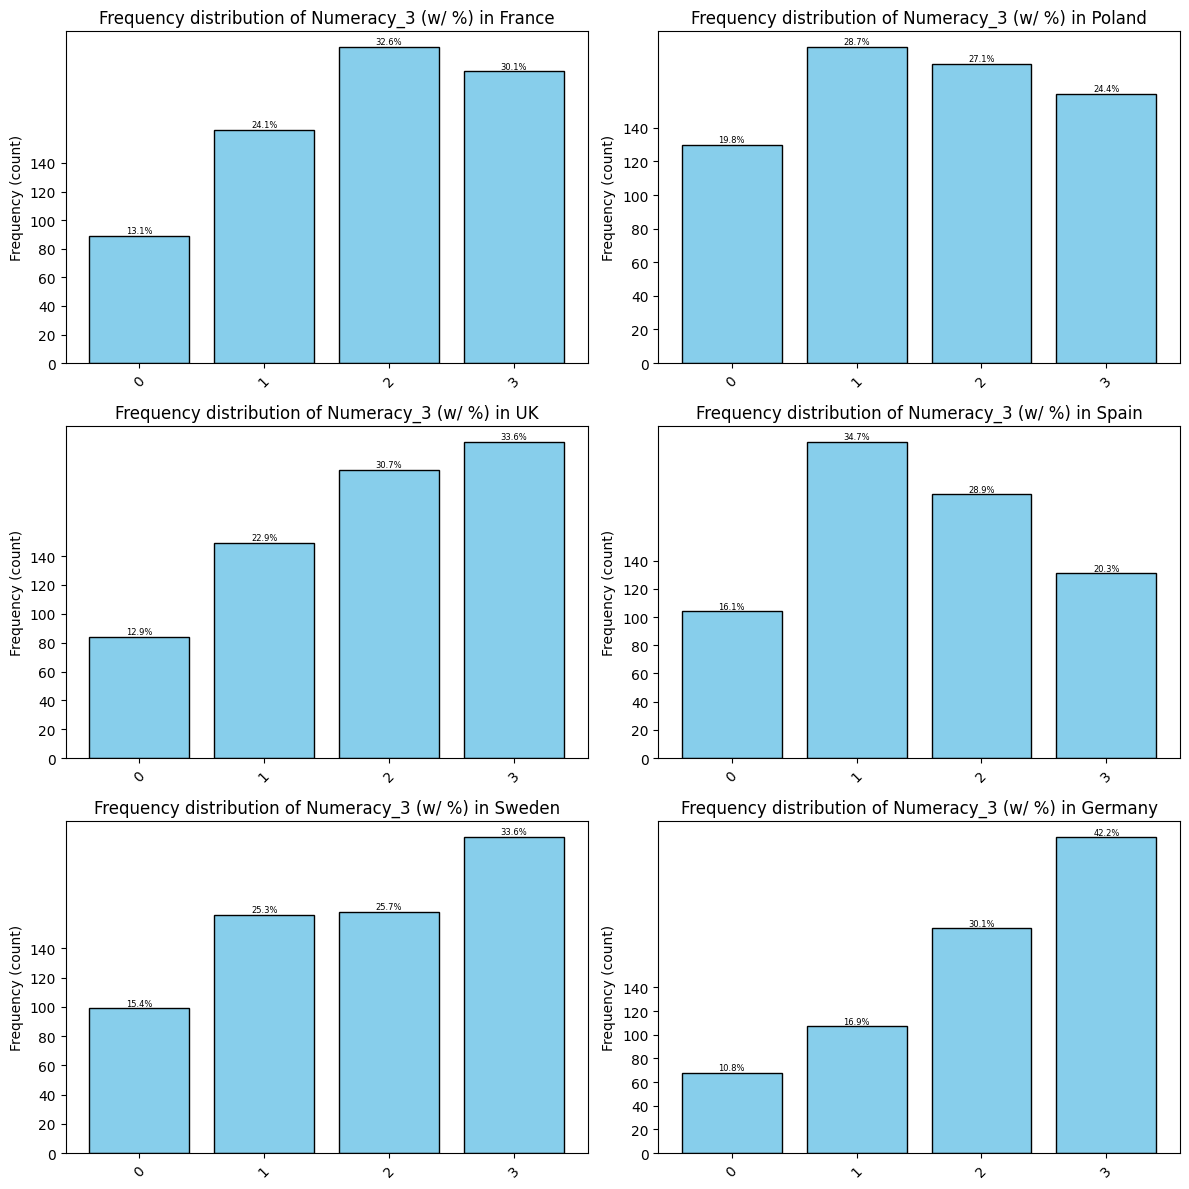

In [8]:
fig, axes = plt.subplots(3, 2, figsize = [12, 12])
axes = axes.flatten()

countries = euro["country_text"].value_counts().index.to_list()

for i, country in enumerate(countries):
    sample = euro.loc[euro["country_text"] == country, "Numeracy_3"].value_counts().sort_index()
    x = sample.index
    y = sample.values
    total = sample.sum() 
    
    axes[i].bar(x, y, color="skyblue", edgecolor='black')
    
    for j, value in zip(sample.index, sample.values):
        axes[i].text(j, value + 0.5, f"{value/total * 100:.1f}%", ha = "center", va = "bottom", fontsize=6, color="black")
    
    axes[i].set_yticks(np.arange(0, 151, step = 20))
    axes[i].set_xticks(x)
    axes[i].set_xticklabels(x, rotation = 45, ha = "center")
    
    axes[i].set_ylabel(f"Frequency (count)")
    axes[i].set_title(f"Frequency distribution of Numeracy_3 (w/ %) in {country}")

plt.tight_layout()
plt.show()

#### 2. Frequency distribution of graph literacy scores (sum of correct responses)

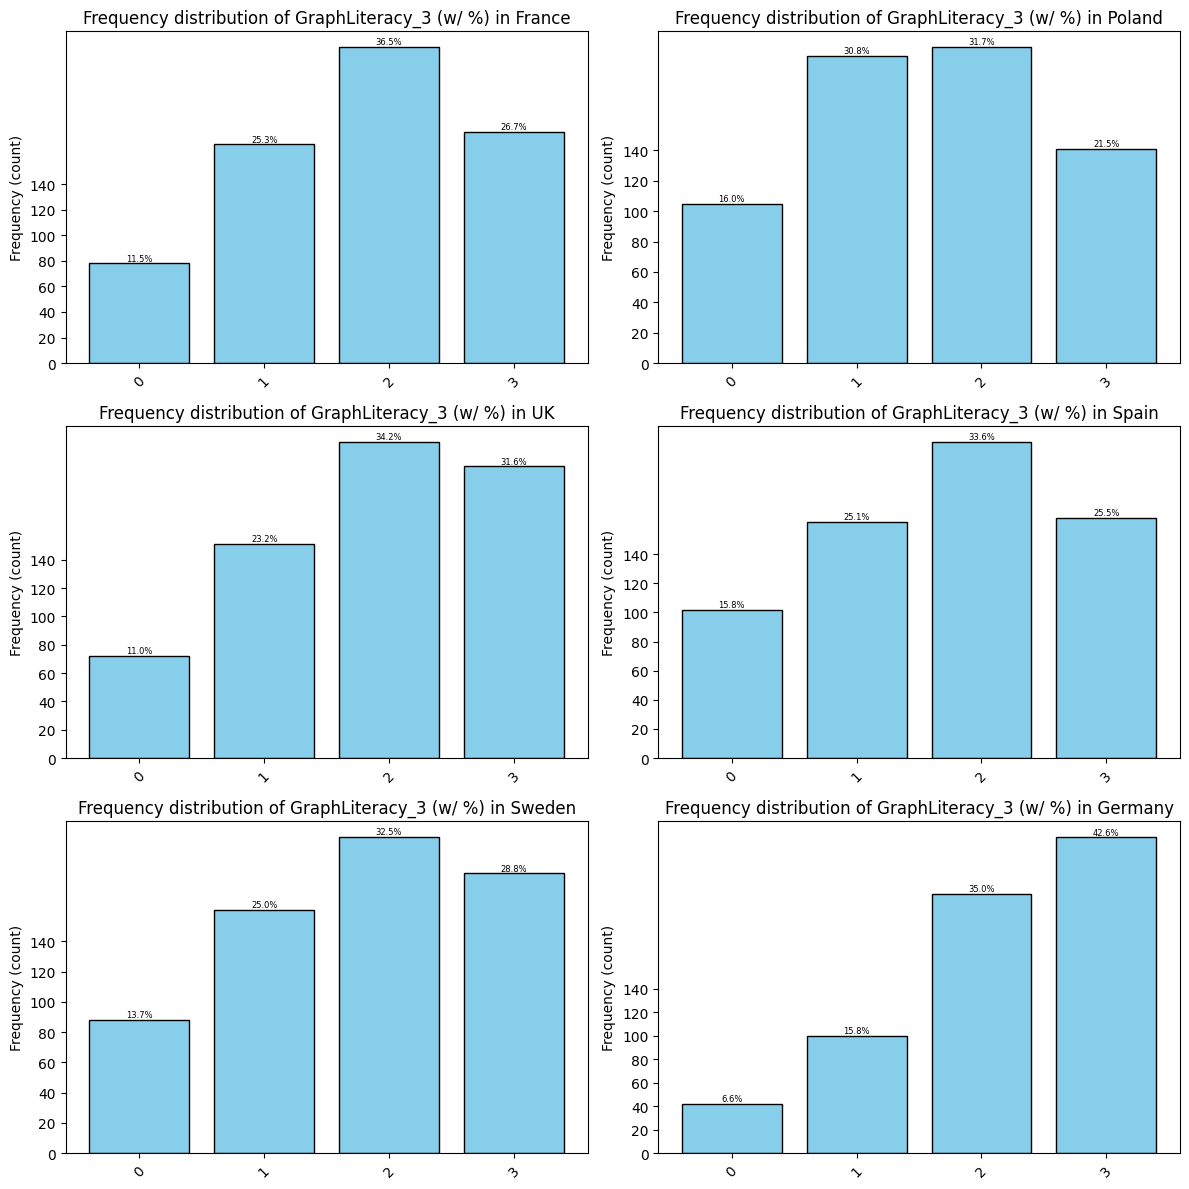

In [9]:
fig, axes = plt.subplots(3, 2, figsize = [12, 12])
axes = axes.flatten()

countries = euro["country_text"].value_counts().index.to_list()

for i, country in enumerate(countries):
    sample = euro.loc[euro["country_text"] == country, "GraphLiteracy_3"].value_counts().sort_index()
    x = sample.index
    y = sample.values
    total = sample.sum() 
    
    axes[i].bar(x, y, color="skyblue", edgecolor='black')
    
    for j, value in zip(sample.index, sample.values):
        axes[i].text(j, value + 0.5, f"{value/total * 100:.1f}%", ha = "center", va = "bottom", fontsize=6, color="black")
    
    axes[i].set_yticks(np.arange(0, 151, step = 20))
    axes[i].set_xticks(x)
    axes[i].set_xticklabels(x, rotation = 45, ha = "center")
    
    axes[i].set_ylabel(f"Frequency (count)")
    axes[i].set_title(f"Frequency distribution of GraphLiteracy_3 (w/ %) in {country}")

plt.tight_layout()
plt.show()

### ii. Descriptive statistics (Europe=6 countries)

#### Show the relationship between sum of numeracy+graph literacy and wealth [all age]stratified by education

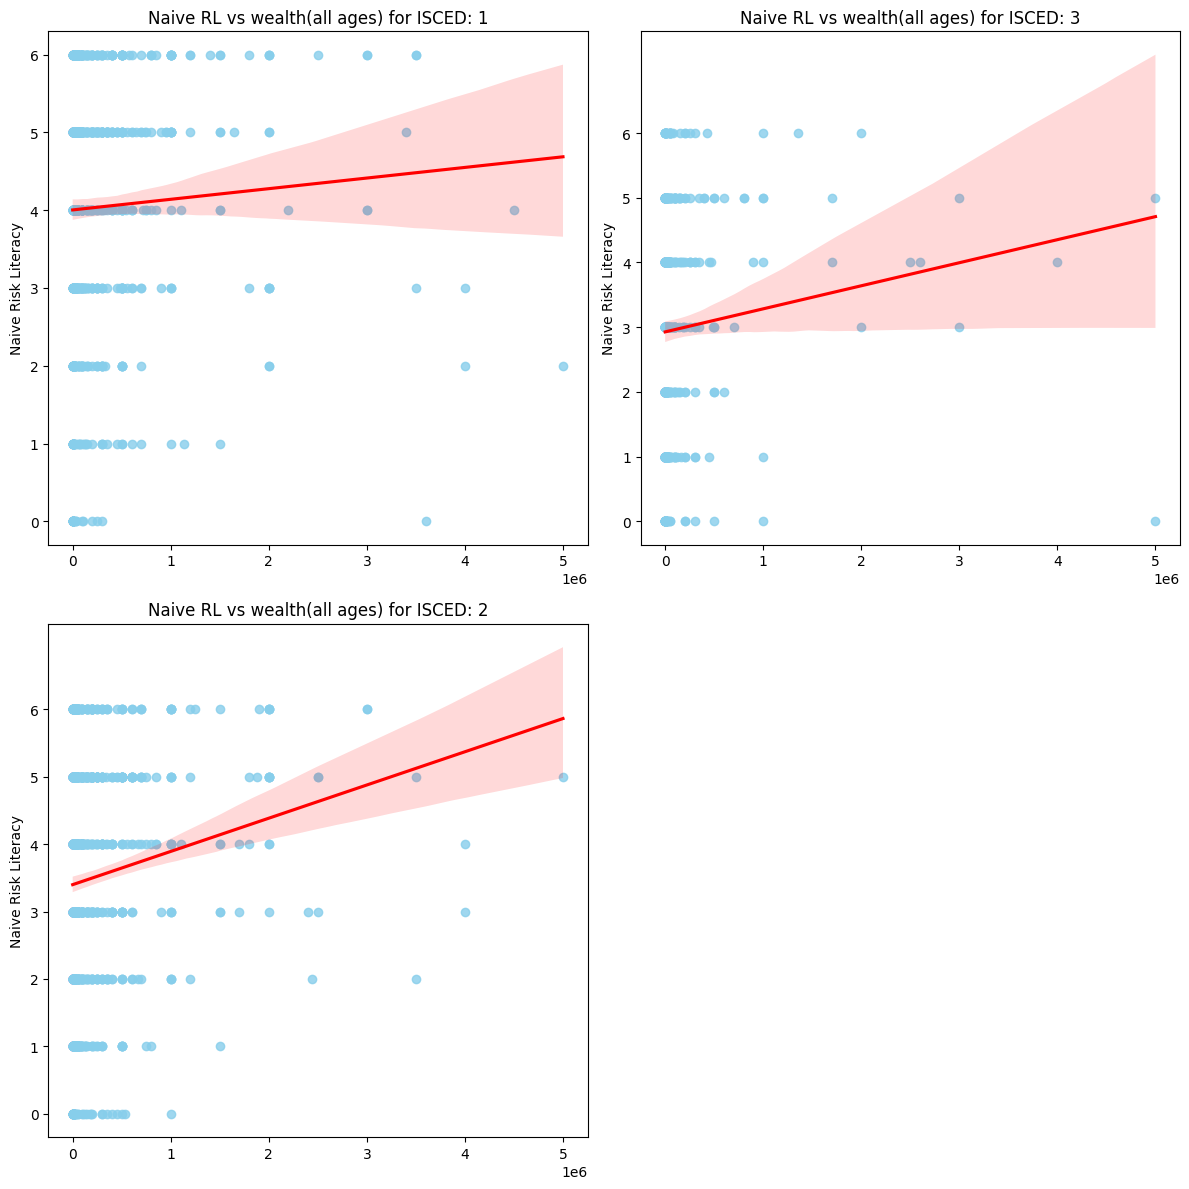

In [10]:
fig, axes = plt.subplots(2, 2, figsize = [12, 12])
axes = axes.flatten()

isced = euro["isced"].unique()

for i, edu in enumerate(isced):
    sample = euro.loc[(euro["isced"] == edu) & (euro["wealth"] != -1)].copy()
    x = sample["wealth"].values
    y = sample["Naive_RL_6"].values
    total = sample.sum() 
    
    sns.regplot(x=x, y=y, color="skyblue", ax = axes[i], line_kws={"color": "red"})

    axes[i].set_yticks(np.arange(0, 7, step = 1))
    
    axes[i].set_ylabel(f"Naive Risk Literacy")
    axes[i].set_title(f"Naive RL vs wealth(all ages) for ISCED: {edu}")


fig.delaxes(axes[i+1])
plt.tight_layout()
plt.show()

Show the relationship between sum of numeracy+graph literacy and income [31-59y] stratified by education

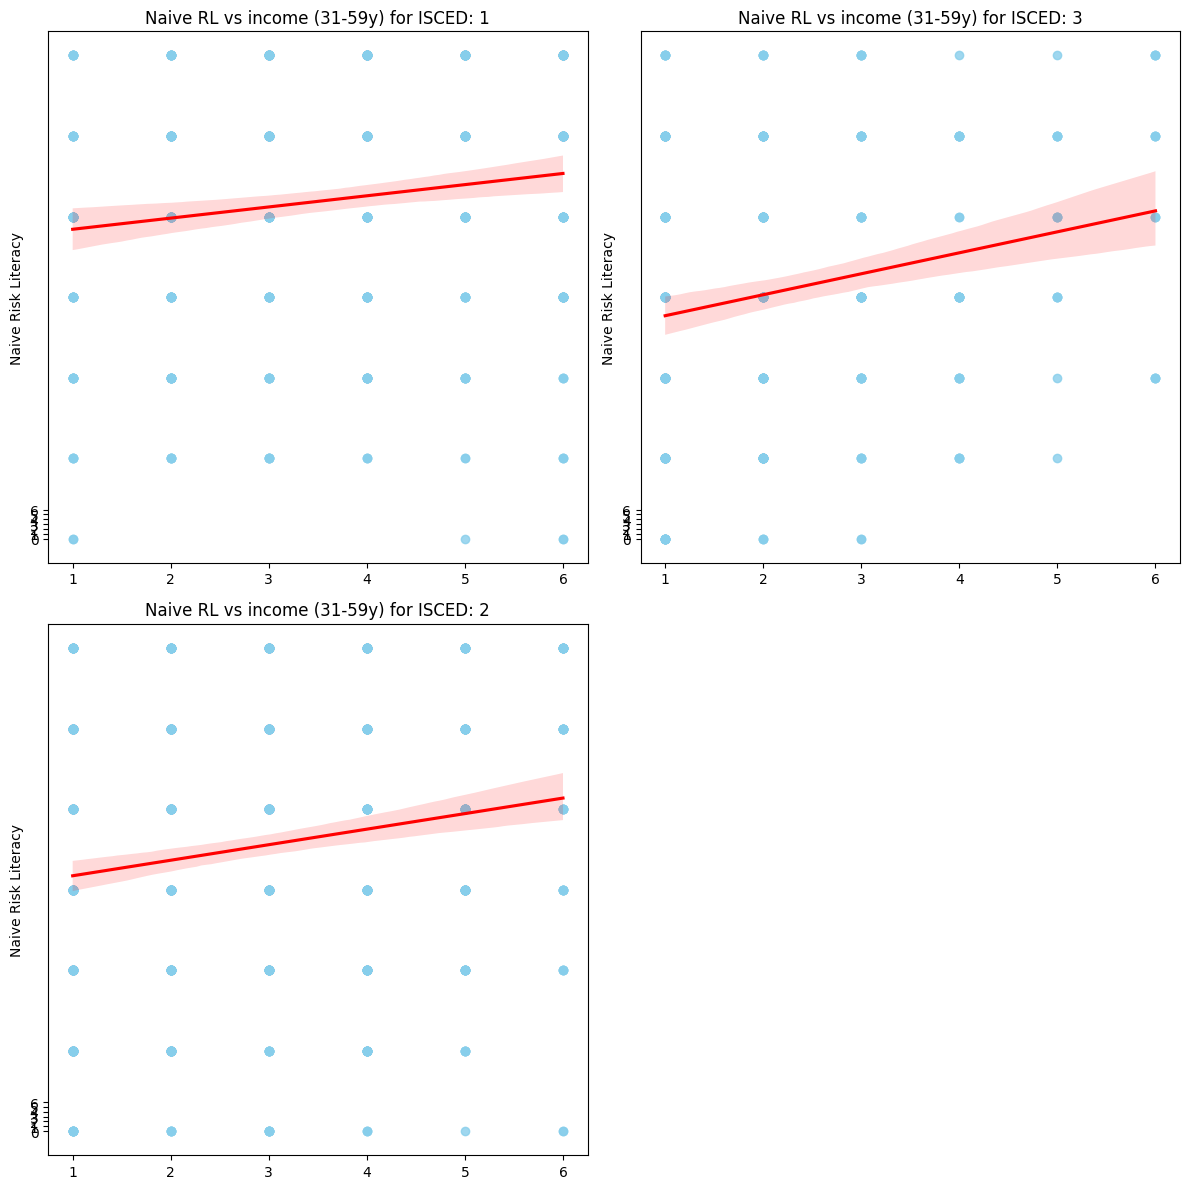

In [11]:
fig, axes = plt.subplots(2, 2, figsize = [12, 12])
axes = axes.flatten()

isced = euro["isced"].unique()

for i, edu in enumerate(isced):
    sample = euro.loc[
        (euro["isced"] == edu)
        & (euro["income"] != -1)
        & (euro["age_rec"] == 3)].copy()
    
    x = sample["income"].values
    y = sample["Naive_RL_%"].values
    total = sample.sum() 
    
    sns.regplot(x=x, y=y, color="skyblue", ax = axes[i], line_kws={"color": "red"})

    axes[i].set_yticks(np.arange(0, 7, step = 1))
    
    axes[i].set_ylabel(f"Naive Risk Literacy")
    axes[i].set_title(f"Naive RL vs income (31-59y) for ISCED: {edu}")


fig.delaxes(axes[i+1])
plt.tight_layout()
plt.show()

### iii. Appendix

#### Correlation matrix between numeracy, graph literacy, demographics

In [12]:
cols = ["Numeracy_3", "GraphLiteracy_3","age_rec", "isced"]
corr_matrix = euro[cols].corr()
print(corr_matrix)

                 Numeracy_3  GraphLiteracy_3   age_rec     isced
Numeracy_3         1.000000         0.424088  0.028958 -0.229742
GraphLiteracy_3    0.424088         1.000000 -0.001792 -0.163469
age_rec            0.028958        -0.001792  1.000000  0.125614
isced             -0.229742        -0.163469  0.125614  1.000000


### iv. Inference statistics (Europe=6 countries)

#### Numeracy: Regressions

##### Predicting wealth: covariates(proxy to general intelligence), age (proxy to cohort)

In [13]:
data = euro.loc[euro["wealth"] != -1].copy()

model = sm.OLS(data["wealth"], sm.add_constant(data[["Numeracy_3", "age_rec"]]))

# Age group 2 = 18 to 35 y/o
# Age group 3 = 36 to 55 y/o
# Age group 4 = 56 to 75 y/o 

res = model.fit()
print(res.summary())

                            OLS Regression Results                            
Dep. Variable:                 wealth   R-squared:                       0.027
Model:                            OLS   Adj. R-squared:                  0.026
Method:                 Least Squares   F-statistic:                     29.79
Date:                Wed, 22 Oct 2025   Prob (F-statistic):           1.72e-13
Time:                        14:43:52   Log-Likelihood:                -31902.
No. Observations:                2187   AIC:                         6.381e+04
Df Residuals:                    2184   BIC:                         6.383e+04
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const      -6.453e+04   4.92e+04     -1.312      0.1

##### Predicting wealth: income when analysing wealth

In [14]:
data = euro.loc[
    (euro["wealth"] != -1)
    & (euro["income"] != -1)].copy()

model = sm.OLS(data["wealth"], sm.add_constant(
    data[["Numeracy_3", "age_rec", "income"]]))

# Age group 2 = 18 to 35 y/o
# Age group 3 = 36 to 55 y/o
# Age group 4 = 56 to 75 y/o 

res = model.fit()
print(res.summary())

                            OLS Regression Results                            
Dep. Variable:                 wealth   R-squared:                       0.081
Model:                            OLS   Adj. R-squared:                  0.079
Method:                 Least Squares   F-statistic:                     62.74
Date:                Wed, 22 Oct 2025   Prob (F-statistic):           7.04e-39
Time:                        14:43:52   Log-Likelihood:                -31254.
No. Observations:                2146   AIC:                         6.252e+04
Df Residuals:                    2142   BIC:                         6.254e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const      -2.727e+05   5.21e+04     -5.233      0.0

##### Predicting income: covariates(proxy to general intelligence), age (proxy to cohort)

In [15]:
data = euro.loc[euro["income"] != -1].copy()

model = sm.OLS(data["income"], sm.add_constant(data[["Numeracy_3", "age_rec"]]))

# Age group 2 = 18 to 35 y/o
# Age group 3 = 36 to 55 y/o
# Age group 4 = 56 to 75 y/o 

res = model.fit()
print(res.summary())

                            OLS Regression Results                            
Dep. Variable:                 income   R-squared:                       0.036
Model:                            OLS   Adj. R-squared:                  0.036
Method:                 Least Squares   F-statistic:                     63.66
Date:                Wed, 22 Oct 2025   Prob (F-statistic):           7.26e-28
Time:                        14:43:52   Log-Likelihood:                -6214.0
No. Observations:                3371   AIC:                         1.243e+04
Df Residuals:                    3368   BIC:                         1.245e+04
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          2.4205      0.116     20.792      0.0

#### Graph Literacy: Regressions

##### Predicting wealth: covariates(proxy to general intelligence), age (proxy to cohort)

In [16]:
data = euro.loc[euro["wealth"] != -1].copy()

model = sm.OLS(data["wealth"], sm.add_constant(data[["GraphLiteracy_3", "age_rec"]]))

# Age group 2 = 18 to 35 y/o
# Age group 3 = 36 to 55 y/o
# Age group 4 = 56 to 75 y/o 

res = model.fit()
print(res.summary())

                            OLS Regression Results                            
Dep. Variable:                 wealth   R-squared:                       0.011
Model:                            OLS   Adj. R-squared:                  0.010
Method:                 Least Squares   F-statistic:                     11.62
Date:                Wed, 22 Oct 2025   Prob (F-statistic):           9.54e-06
Time:                        14:43:52   Log-Likelihood:                -31920.
No. Observations:                2187   AIC:                         6.385e+04
Df Residuals:                    2184   BIC:                         6.386e+04
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const           -3773.1888   5.01e+04     

##### Predicting wealth: income when analysing wealth

In [17]:
data = euro.loc[
    (euro["wealth"] != -1)
    & (euro["income"] != -1)].copy()

model = sm.OLS(data["wealth"].abs(), sm.add_constant(data[["GraphLiteracy_3", "age_rec", "income"]]))

# Age group 2 = 18 to 35 y/o
# Age group 3 = 36 to 55 y/o
# Age group 4 = 56 to 75 y/o 

res = model.fit()
print(res.summary())

                            OLS Regression Results                            
Dep. Variable:                 wealth   R-squared:                       0.075
Model:                            OLS   Adj. R-squared:                  0.073
Method:                 Least Squares   F-statistic:                     57.54
Date:                Wed, 22 Oct 2025   Prob (F-statistic):           9.02e-36
Time:                        14:43:52   Log-Likelihood:                -31261.
No. Observations:                2146   AIC:                         6.253e+04
Df Residuals:                    2142   BIC:                         6.255e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const           -2.473e+05   5.34e+04     

##### Predicting income: covariates(proxy to general intelligence), age (proxy to cohort)

In [18]:
data = euro.loc[euro["income"] != -1].copy()

model = sm.OLS(data["income"].abs(), sm.add_constant(data[["GraphLiteracy_3", "age_rec"]]))

# Age group 2 = 18 to 35 y/o
# Age group 3 = 36 to 55 y/o
# Age group 4 = 56 to 75 y/o 

res = model.fit()
print(res.summary())

                            OLS Regression Results                            
Dep. Variable:                 income   R-squared:                       0.010
Model:                            OLS   Adj. R-squared:                  0.010
Method:                 Least Squares   F-statistic:                     17.41
Date:                Wed, 22 Oct 2025   Prob (F-statistic):           3.01e-08
Time:                        14:43:52   Log-Likelihood:                -6259.2
No. Observations:                3371   AIC:                         1.252e+04
Df Residuals:                    3368   BIC:                         1.254e+04
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const               2.6008      0.120     

### iv. Exploratory analysis: Naive RL

##### Predicting wealth: covariates(proxy to general intelligence), age (proxy to cohort)

In [19]:
data = euro.loc[euro["wealth"] != -1].copy()

model = sm.OLS(data["wealth"], sm.add_constant(data[["Naive_RL_6", "age_rec"]]))

# Age group 2 = 18 to 35 y/o
# Age group 3 = 36 to 55 y/o
# Age group 4 = 56 to 75 y/o 

res = model.fit()
print(res.summary())

                            OLS Regression Results                            
Dep. Variable:                 wealth   R-squared:                       0.021
Model:                            OLS   Adj. R-squared:                  0.020
Method:                 Least Squares   F-statistic:                     23.15
Date:                Wed, 22 Oct 2025   Prob (F-statistic):           1.12e-10
Time:                        14:43:52   Log-Likelihood:                -31908.
No. Observations:                2187   AIC:                         6.382e+04
Df Residuals:                    2184   BIC:                         6.384e+04
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const      -6.841e+04   5.08e+04     -1.347      0.1

##### Predicting wealth: income when analysing wealth

In [20]:
data = euro.loc[
    (euro["wealth"] != -1)
    & (euro["income"] != -1)].copy()

model = sm.OLS(data["wealth"].abs(), sm.add_constant(data[["Naive_RL_6", "age_rec", "income"]]))

# Age group 2 = 18 to 35 y/o
# Age group 3 = 36 to 55 y/o
# Age group 4 = 56 to 75 y/o 

res = model.fit()
print(res.summary())

                            OLS Regression Results                            
Dep. Variable:                 wealth   R-squared:                       0.078
Model:                            OLS   Adj. R-squared:                  0.077
Method:                 Least Squares   F-statistic:                     60.75
Date:                Wed, 22 Oct 2025   Prob (F-statistic):           1.08e-37
Time:                        14:43:52   Log-Likelihood:                -31256.
No. Observations:                2146   AIC:                         6.252e+04
Df Residuals:                    2142   BIC:                         6.254e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const      -2.792e+05   5.35e+04     -5.224      0.0

##### Predicting income: covariates(proxy to general intelligence), age (proxy to cohort)

In [21]:
data = euro.loc[euro["income"] != -1].copy()

model = sm.OLS(data["income"].abs(), sm.add_constant(data[["Naive_RL_6", "age_rec"]]))

# Age group 2 = 18 to 35 y/o
# Age group 3 = 36 to 55 y/o
# Age group 4 = 56 to 75 y/o 

res = model.fit()
print(res.summary())

                            OLS Regression Results                            
Dep. Variable:                 income   R-squared:                       0.030
Model:                            OLS   Adj. R-squared:                  0.030
Method:                 Least Squares   F-statistic:                     52.90
Date:                Wed, 22 Oct 2025   Prob (F-statistic):           2.40e-23
Time:                        14:43:52   Log-Likelihood:                -6224.4
No. Observations:                3371   AIC:                         1.245e+04
Df Residuals:                    3368   BIC:                         1.247e+04
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          2.3456      0.121     19.368      0.0

---

---

# 2. Study 2: Dynata 1 (India)

### a. What is this study adding?

 i. Representativeness in terms of year 2025

ii. Representativeness in terms of global south

iii. Exploration of the illusion of certainty – Creating a measure with

iv. Indicate mechanisms of how wealth generation might be affected by risk literacy(explanation of the relationship with wealth)


### b. Methods
---

IMPORTANT ASSUMPTIONS:
1. Wealth windsorization @ 1%, both ends
---

### Data preparation and sample stats

In [22]:
import_folder_path = rf"../india_dynata"
df00 = pd.read_pickle(rf"{import_folder_path}/India_Dynata_dataset_scoredOnly.pkl")


       winsorised_wealth  nonwinsorised_wealth
count       6.990000e+02          6.990000e+02
mean        7.060813e+06          1.628566e+08
std         2.068795e+07          3.794346e+09
min         0.000000e+00          0.000000e+00
25%         1.000000e+05          1.000000e+05
50%         6.000000e+05          6.000000e+05
75%         4.000000e+06          4.000000e+06
max         1.500000e+08          1.000000e+11


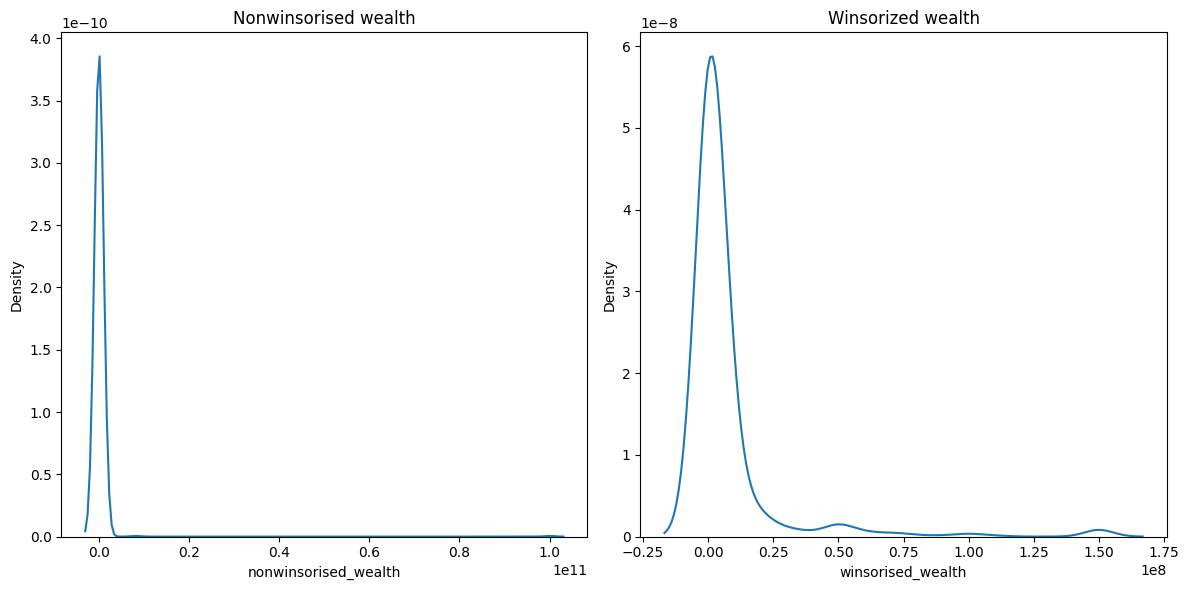

In [23]:
# Any additional data wrangle:
# NAIVE RL caluclation
df00["Naive_RL_6"] = df00["GraphLiteracy_3"] + df00["Numeracy_3"]
df00["Naive_RL_%"] = df00["Naive_RL_6"] / 6 * 100

df00["Naive_RL_certainty_11"] = df00["GraphLiteracy_3"] + df00["Numeracy_3"] + df00["Certainty_5"]
df00["Naive_RL_certainty_%"] = df00["Naive_RL_certainty_11"] / 11 * 100

# Windorized wealth at 1% both end
winsorized_wealth = winsorize_output(df00, "wealth", [0.01, 0.01])
# Using winsorised wealth as wealth
df00["wealth"] = winsorized_wealth

In [24]:
# print("Total Observations:", df00["Q1"].count())

print(f'\nGender:\n{remove_indexname(df00["gender_text"].value_counts())}')
print('-' * 100)
print(f'ISCED:\n{remove_indexname(df00["isced"].value_counts().sort_index())}')
print('-' * 100)
# print(f'Income:\n{remove_indexname(df00["income_text"].value_counts().sort_index())}')
print(f'\nIncome_code:\n{remove_indexname(df00["income"].value_counts().sort_index())}')
print('-' * 100)
print(f'Countries:\n{remove_indexname(df00["country_text"].value_counts())}')
print(f'\nCountries_code:\n{remove_indexname(df00["country"].value_counts())}')
print('-' * 100)

ind_dyn1 = df00.copy()
# print(f'\nOccupation:\n{remove_indexname(df0["Q4a"].value_counts())}')
# print(f'\nEducation:\n{remove_indexname(df0["Q3"].value_counts())}')


Gender:
Male      361
Female    338
----------------------------------------------------------------------------------------------------
ISCED:
1    252
2    241
3    206
----------------------------------------------------------------------------------------------------

Income_code:
1    194
2    221
3    114
4     76
5     52
6     42
----------------------------------------------------------------------------------------------------
Countries:
India    699

Countries_code:
0    699
----------------------------------------------------------------------------------------------------


### c. Results

#### i. Descriptive Statistics - NAIVE RL (numeracy + graph)

#### Show the relationship between sum of numeracy+graph literacy and wealth [all age]stratified by education

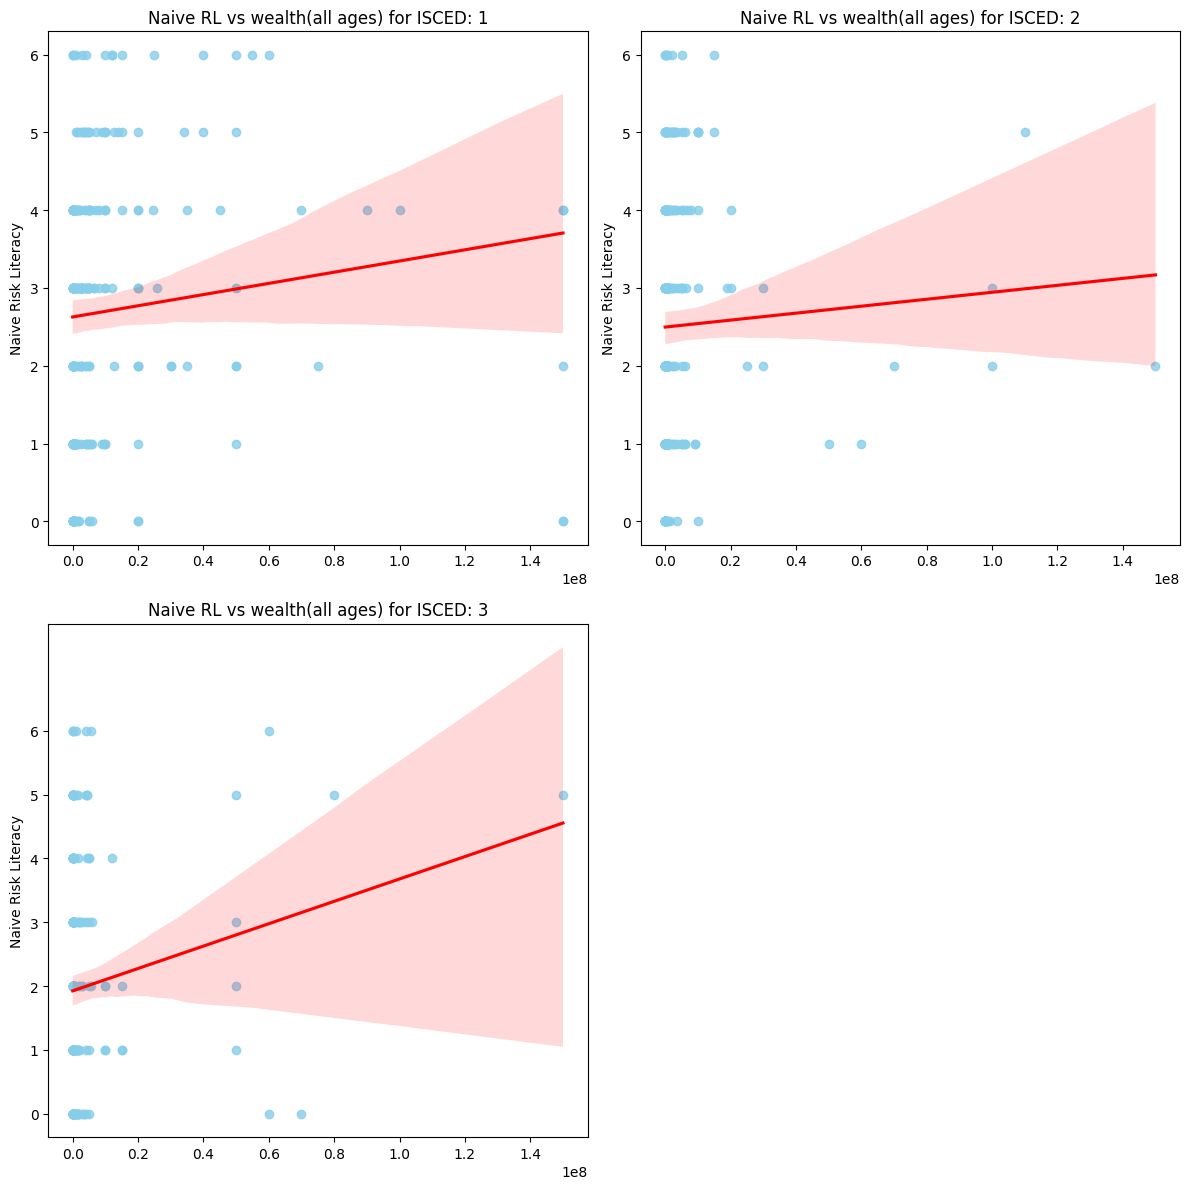

In [25]:
fig, axes = plt.subplots(2, 2, figsize = [12, 12])
axes = axes.flatten()

isced = ind_dyn1["isced"].unique()

for i, edu in enumerate(isced):
    sample = ind_dyn1.loc[(ind_dyn1["isced"] == edu) & (ind_dyn1["wealth"] != -1)].copy()
    x = sample["wealth"].values
    y = sample["Naive_RL_6"].values
    total = sample.sum() 
    
    sns.regplot(x=x, y=y, color="skyblue", ax = axes[i], line_kws={"color": "red"})

    axes[i].set_yticks(np.arange(0, 7, step = 1))
    
    axes[i].set_ylabel(f"Naive Risk Literacy")
    axes[i].set_title(f"Naive RL vs wealth(all ages) for ISCED: {edu}")


fig.delaxes(axes[i+1])
plt.tight_layout()
plt.show()

#### Show the relationship between sum of numeracy+graph literacy and income [31-59y] stratified by education

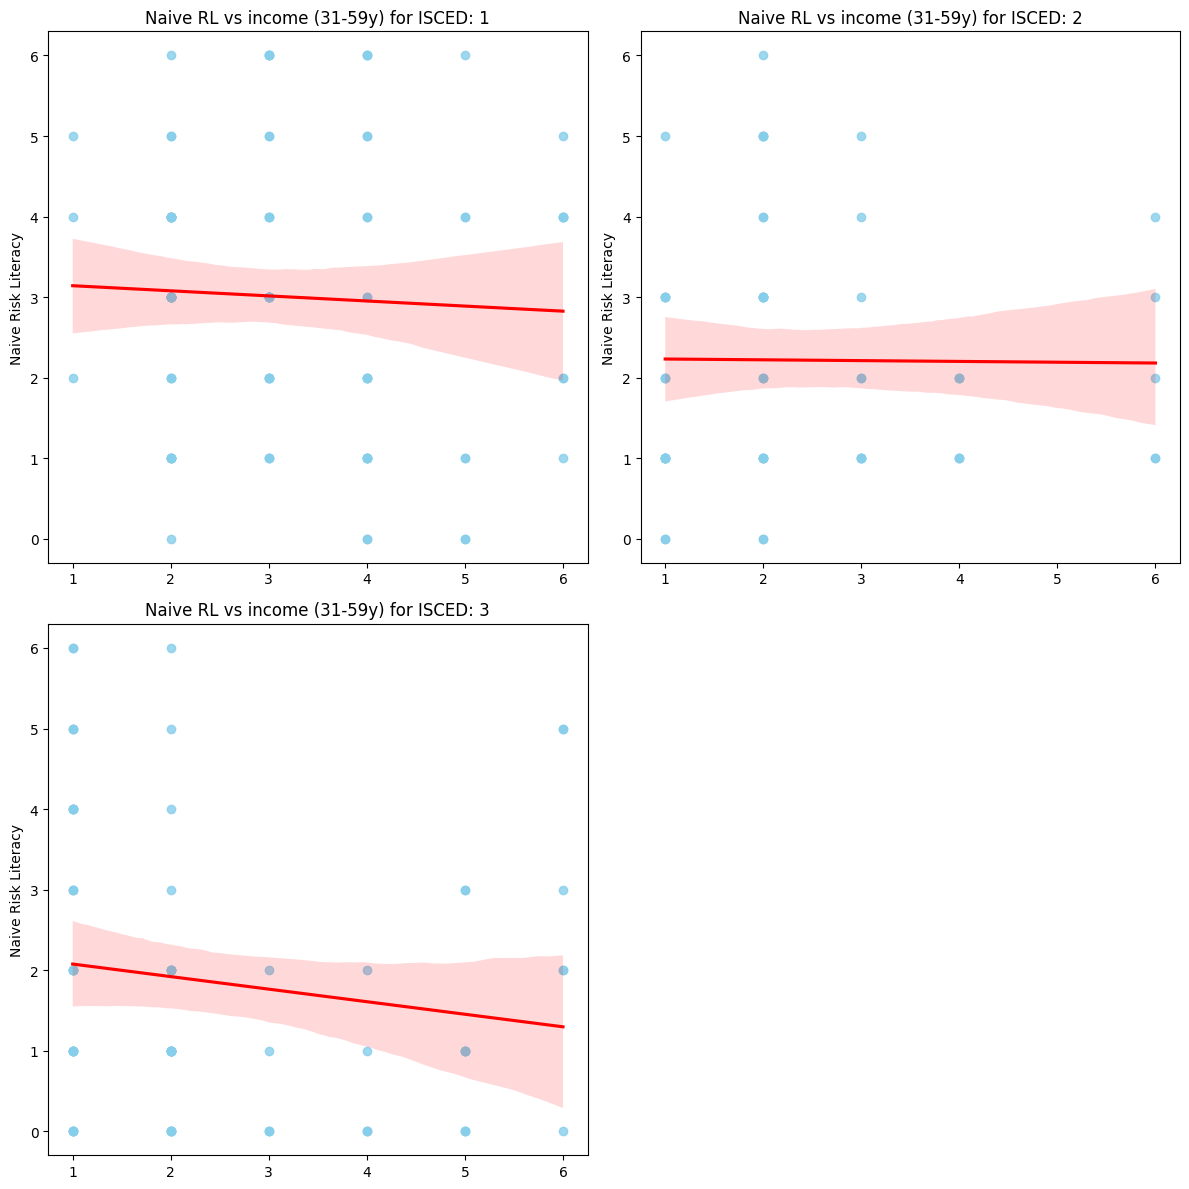

In [26]:
fig, axes = plt.subplots(2, 2, figsize = [12, 12])
axes = axes.flatten()

isced = ind_dyn1["isced"].unique()

for i, edu in enumerate(isced):
    sample = ind_dyn1.loc[
        (ind_dyn1["isced"] == edu)
        & (ind_dyn1["income"] != -1)
        & (ind_dyn1["age_rec"] == 3)].copy()
    
    x = sample["income"].values
    y = sample["Naive_RL_6"].values
    total = sample.sum() 
    
    sns.regplot(x=x, y=y, color="skyblue", ax = axes[i], line_kws={"color": "red"})

    axes[i].set_yticks(np.arange(0, 7, step = 1))
    
    axes[i].set_ylabel(f"Naive Risk Literacy")
    axes[i].set_title(f"Naive RL vs income (31-59y) for ISCED: {edu}")


fig.delaxes(axes[i+1])
plt.tight_layout()
plt.show()

### ii. Total literacy MEAN (=proportion correct of Numeracy, proportion correct of graph literacy)

#### Regressions

##### Predicting wealth: covariates(proxy to general intelligence), age (proxy to cohort), crt, financial literacy, Risk preference

In [27]:
data = ind_dyn1.loc[ind_dyn1["wealth"] != -1].copy()

model = sm.OLS(data["wealth"], sm.add_constant(
    data[["Naive_RL_%", "age_rec", "CRTScore_3", "FinancialLiteracy_3",
          "RiskAppetite_7"]]))

# Age group 2 = 18 to 35 y/o
# Age group 3 = 36 to 55 y/o
# Age group 4 = 56 to 75 y/o 

res = model.fit()
print(res.summary())

                            OLS Regression Results                            
Dep. Variable:                 wealth   R-squared:                       0.033
Model:                            OLS   Adj. R-squared:                  0.026
Method:                 Least Squares   F-statistic:                     4.690
Date:                Wed, 22 Oct 2025   Prob (F-statistic):           0.000322
Time:                        14:43:54   Log-Likelihood:                -12754.
No. Observations:                 699   AIC:                         2.552e+04
Df Residuals:                     693   BIC:                         2.555e+04
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
const               -7.777e+06   4

##### Predicting wealth: income when analysing wealth

In [28]:
data = ind_dyn1.loc[
    (ind_dyn1["wealth"] != -1)
    & (ind_dyn1["income"] != -1)].copy()

model = sm.OLS(data["wealth"], sm.add_constant(data[[
    "Naive_RL_%", "age_rec", "CRTScore_3", "FinancialLiteracy_3",
    "RiskAppetite_7", "income"]]))

# Age group 2 = 18 to 35 y/o
# Age group 3 = 36 to 55 y/o
# Age group 4 = 56 to 75 y/o 

res = model.fit()
print(res.summary())

                            OLS Regression Results                            
Dep. Variable:                 wealth   R-squared:                       0.101
Model:                            OLS   Adj. R-squared:                  0.094
Method:                 Least Squares   F-statistic:                     13.02
Date:                Wed, 22 Oct 2025   Prob (F-statistic):           5.55e-14
Time:                        14:43:54   Log-Likelihood:                -12729.
No. Observations:                 699   AIC:                         2.547e+04
Df Residuals:                     692   BIC:                         2.550e+04
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
const               -1.254e+07   3

##### Predicting income: covariates(proxy to general intelligence), age (proxy to cohort), crt, financial literacy, Risk preference

In [29]:
data = ind_dyn1.loc[ind_dyn1["income"] != -1].copy()

model = sm.OLS(data["income"], sm.add_constant(
    data[["Naive_RL_%", "age_rec","CRTScore_3", "FinancialLiteracy_3",
          "RiskAppetite_7"]]))

# Age group 2 = 18 to 35 y/o
# Age group 3 = 36 to 55 y/o
# Age group 4 = 56 to 75 y/o 

res = model.fit()
print(res.summary())

                            OLS Regression Results                            
Dep. Variable:                 income   R-squared:                       0.138
Model:                            OLS   Adj. R-squared:                  0.131
Method:                 Least Squares   F-statistic:                     22.11
Date:                Wed, 22 Oct 2025   Prob (F-statistic):           1.37e-20
Time:                        14:43:54   Log-Likelihood:                -1213.4
No. Observations:                 699   AIC:                             2439.
Df Residuals:                     693   BIC:                             2466.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                   1.2063    

#### Predicting Behaviours: ESTABLISHED MEASURES

##### Self reported emergency savings

In [30]:
data = ind_dyn1.copy()

model = sm.OLS(data["financialplanning_emergency"], sm.add_constant(
    data[["Naive_RL_%", "age_rec","CRTScore_3", "FinancialLiteracy_3",
          "RiskAppetite_7"]]))

# Age group 2 = 18 to 35 y/o
# Age group 3 = 36 to 55 y/o
# Age group 4 = 56 to 75 y/o 

res = model.fit()
print(res.summary())

                                 OLS Regression Results                                
Dep. Variable:     financialplanning_emergency   R-squared:                       0.128
Model:                                     OLS   Adj. R-squared:                  0.122
Method:                          Least Squares   F-statistic:                     20.43
Date:                         Wed, 22 Oct 2025   Prob (F-statistic):           4.67e-19
Time:                                 14:43:54   Log-Likelihood:                -1146.5
No. Observations:                          699   AIC:                             2305.
Df Residuals:                              693   BIC:                             2332.
Df Model:                                    5                                         
Covariance Type:                     nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------

##### Self reported retirement savings

In [31]:
data = ind_dyn1.copy()

model = sm.OLS(data["financialplanning_retirement"], sm.add_constant(
    data[["Naive_RL_%", "age_rec","CRTScore_3", "FinancialLiteracy_3",
          "RiskAppetite_7"]]))

# Age group 2 = 18 to 35 y/o
# Age group 3 = 36 to 55 y/o
# Age group 4 = 56 to 75 y/o 

res = model.fit()
print(res.summary())

                                 OLS Regression Results                                 
Dep. Variable:     financialplanning_retirement   R-squared:                       0.181
Model:                                      OLS   Adj. R-squared:                  0.175
Method:                           Least Squares   F-statistic:                     30.71
Date:                          Wed, 22 Oct 2025   Prob (F-statistic):           2.91e-28
Time:                                  14:43:54   Log-Likelihood:                -1147.1
No. Observations:                           699   AIC:                             2306.
Df Residuals:                               693   BIC:                             2334.
Df Model:                                     5                                         
Covariance Type:                      nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
----------------------

#### Predicting Behaviours: NOVEL MEASURES

##### Grade of Diversification across financial instruments' risk classes

In [32]:
assets = [
    'savings_bank', 'fixed_deposits', 'recurring_deposits', 'gov_bonds',
    'corp_bonds', 'mutual_funds', 'stocks', 'real_estate', 'commodities', 'other_invest'
    ]

##### 100% in asset class – vs. 10% in each of the 10 asset classes - READ THE COMMENTS

In [33]:
# Instructed methodology unclear

In [34]:
# !!! PROPOSED METHODOLOGY
# Using STANDARD DEVIATION --> HIGHER the STANDARD DEVIATION, LOWER the diversification
# METHOD: The asset columns are used to calculate ROW WISE STANDARD DEVIATION
#         MEAN across a row will always be 100 (fixed total) / 10 (fixed number of asset classes) = 10
#         This means that if values are say - 100, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0 - high standard deviation
#                                           - 10, 10, 10, 10, 10, 10, 10, 10, 10, 10 - low standard deviation, here 0

ind_dyn1["asset_diverse_stddev"] = (ind_dyn1[assets]).std(axis = 1)

data = ind_dyn1.copy()

model = sm.OLS(data["asset_diverse_stddev"], sm.add_constant(
    data[["Naive_RL_%", "age_rec","CRTScore_3", "FinancialLiteracy_3",
          "RiskAppetite_7"]]))

# Age group 2 = 18 to 35 y/o
# Age group 3 = 36 to 55 y/o
# Age group 4 = 56 to 75 y/o 

res = model.fit()
print(res.summary()) 

                             OLS Regression Results                             
Dep. Variable:     asset_diverse_stddev   R-squared:                       0.080
Model:                              OLS   Adj. R-squared:                  0.073
Method:                   Least Squares   F-statistic:                     11.97
Date:                  Wed, 22 Oct 2025   Prob (F-statistic):           3.91e-11
Time:                          14:43:54   Log-Likelihood:                -2334.0
No. Observations:                   699   AIC:                             4680.
Df Residuals:                       693   BIC:                             4707.
Df Model:                             5                                         
Covariance Type:              nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
const         

##### Metric Diversification (from 0 to 1)

In [35]:
ind_dyn1["asset_diverse_metric"] = (ind_dyn1[assets] != 0).sum(axis = 1) / 10

data = ind_dyn1.copy()

model = sm.OLS(data["asset_diverse_metric"], sm.add_constant(
    data[["Naive_RL_%", "age_rec","CRTScore_3", "FinancialLiteracy_3",
          "RiskAppetite_7"]]))

# Age group 2 = 18 to 35 y/o
# Age group 3 = 36 to 55 y/o
# Age group 4 = 56 to 75 y/o 

res = model.fit()
print(res.summary())                                              

                             OLS Regression Results                             
Dep. Variable:     asset_diverse_metric   R-squared:                       0.074
Model:                              OLS   Adj. R-squared:                  0.067
Method:                   Least Squares   F-statistic:                     11.10
Date:                  Wed, 22 Oct 2025   Prob (F-statistic):           2.67e-10
Time:                          14:43:54   Log-Likelihood:                -87.574
No. Observations:                   699   AIC:                             187.1
Df Residuals:                       693   BIC:                             214.4
Df Model:                             5                                         
Covariance Type:              nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
const         

##### Alignment of Financial allocation with risk preference

##### Absolute difference between risk preference rating and the proportion of investments in the risky assets (among the ten assets)


In [36]:
data = ind_dyn1.copy()

model = sm.OLS(data["RiskAlignment_residual"], sm.add_constant(
    data[["Naive_RL_%", "age_rec","CRTScore_3", "FinancialLiteracy_3",
          "RiskAppetite_7"]]))

# Age group 2 = 18 to 35 y/o
# Age group 3 = 36 to 55 y/o
# Age group 4 = 56 to 75 y/o 

res = model.fit()
print(res.summary())   

                              OLS Regression Results                              
Dep. Variable:     RiskAlignment_residual   R-squared:                       0.499
Model:                                OLS   Adj. R-squared:                  0.496
Method:                     Least Squares   F-statistic:                     138.2
Date:                    Wed, 22 Oct 2025   Prob (F-statistic):          1.38e-101
Time:                            14:43:54   Log-Likelihood:                -3167.3
No. Observations:                     699   AIC:                             6347.
Df Residuals:                         693   BIC:                             6374.
Df Model:                               5                                         
Covariance Type:                nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------

---

#### ii. Descriptive Statistics - NAIVE RL (numeracy + graph) + certainty

In [37]:
# regressor: ind_dyn1["Naive_RL_certainty_%"]

#### Show the relationship between sum of numeracy+graph literacy+certainty and wealth [all age]stratified by education

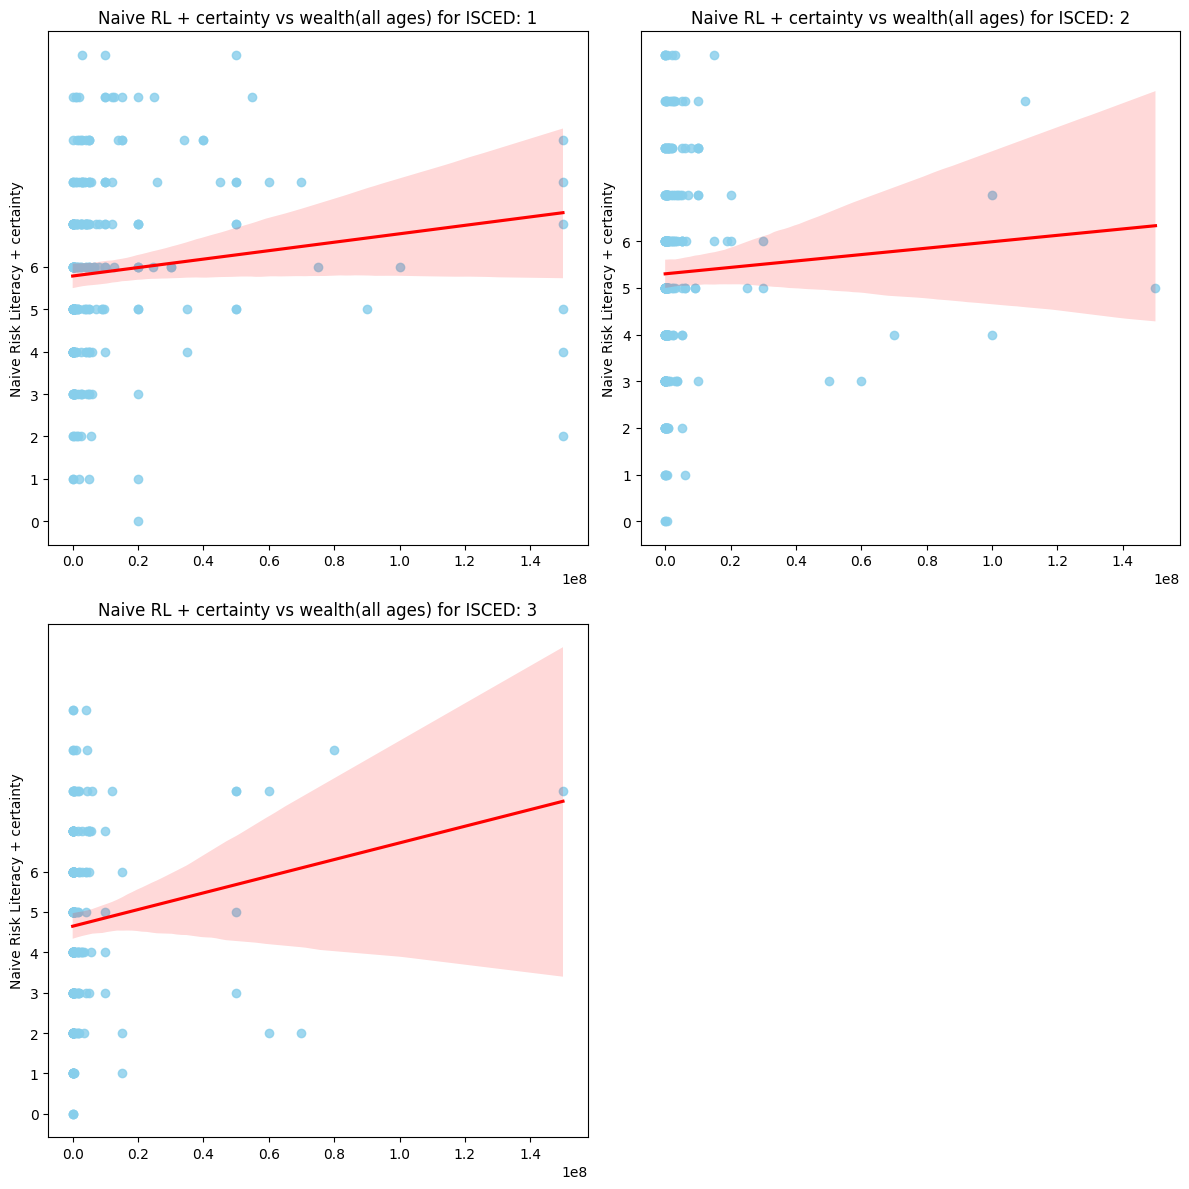

In [38]:
fig, axes = plt.subplots(2, 2, figsize = [12, 12])
axes = axes.flatten()

isced = ind_dyn1["isced"].unique()

for i, edu in enumerate(isced):
    sample = ind_dyn1.loc[(ind_dyn1["isced"] == edu) & (ind_dyn1["wealth"] != -1)].copy()
    x = sample["wealth"].values
    y = sample["Naive_RL_certainty_11"].values
    total = sample.sum() 
    
    sns.regplot(x=x, y=y, color="skyblue", ax = axes[i], line_kws={"color": "red"})

    axes[i].set_yticks(np.arange(0, 7, step = 1))
    
    axes[i].set_ylabel(f"Naive Risk Literacy + certainty")
    axes[i].set_title(f"Naive RL + certainty vs wealth(all ages) for ISCED: {edu}")


fig.delaxes(axes[i+1])
plt.tight_layout()
plt.show()

#### Show the relationship between sum of numeracy+graph literacy+certainty and income [31-59y] stratified by education

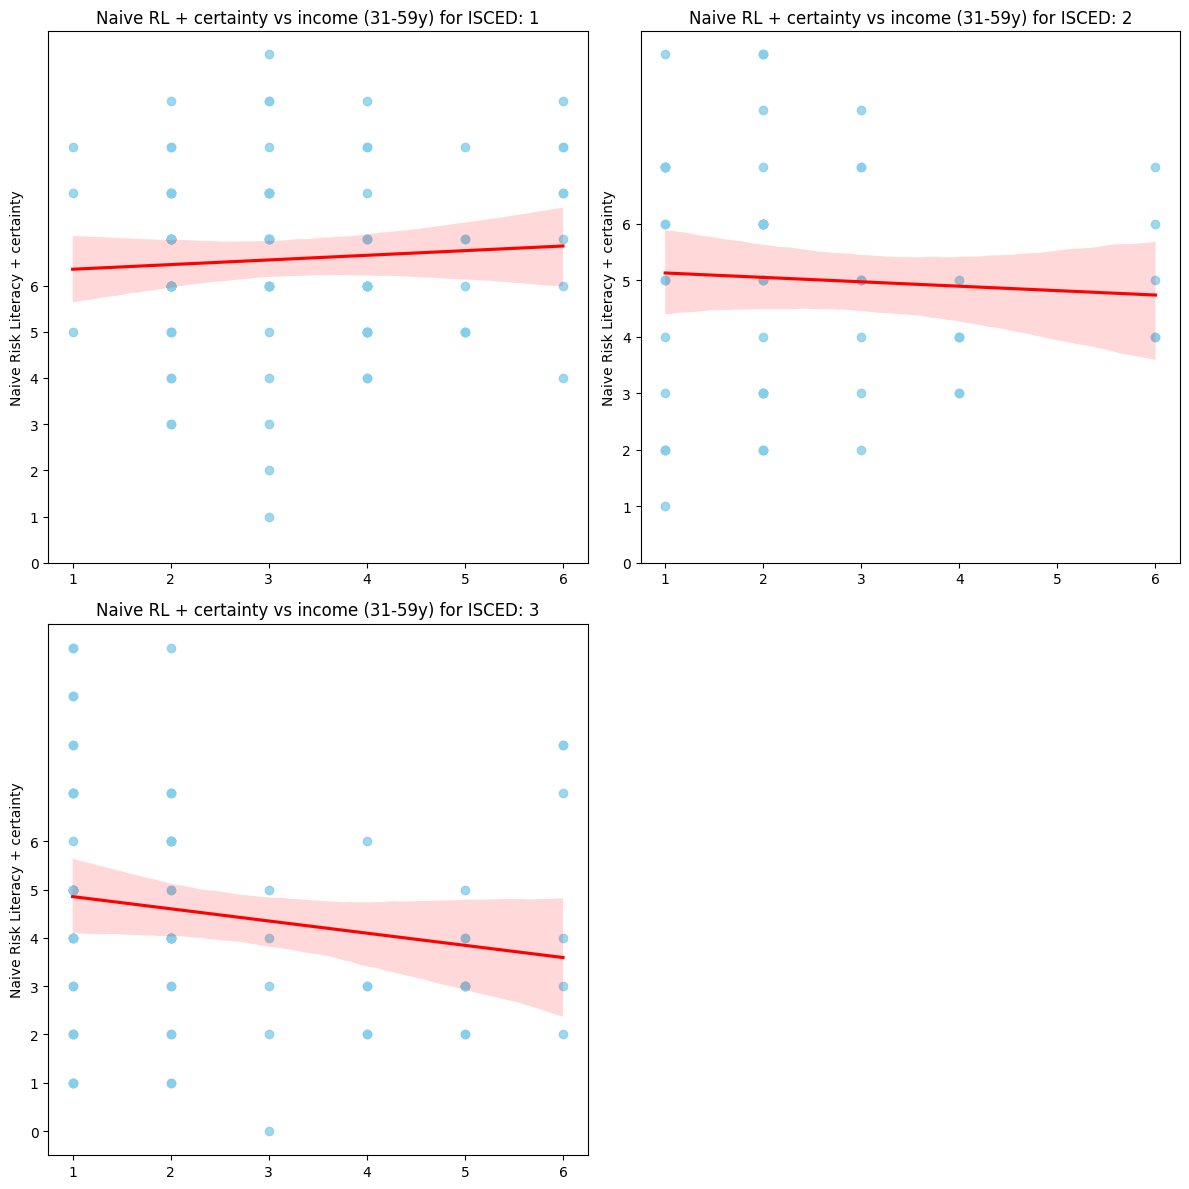

In [39]:
fig, axes = plt.subplots(2, 2, figsize = [12, 12])
axes = axes.flatten()

isced = ind_dyn1["isced"].unique()

for i, edu in enumerate(isced):
    sample = ind_dyn1.loc[
        (ind_dyn1["isced"] == edu)
        & (ind_dyn1["income"] != -1)
        & (ind_dyn1["age_rec"] == 3)].copy()
    
    x = sample["income"].values
    y = sample["Naive_RL_certainty_11"].values
    total = sample.sum() 
    
    sns.regplot(x=x, y=y, color="skyblue", ax = axes[i], line_kws={"color": "red"})

    axes[i].set_yticks(np.arange(0, 7, step = 1))
    
    axes[i].set_ylabel(f"Naive Risk Literacy + certainty")
    axes[i].set_title(f"Naive RL + certainty vs income (31-59y) for ISCED: {edu}")


fig.delaxes(axes[i+1])
plt.tight_layout()
plt.show()

### ii. Total literacy MEAN (=proportion correct of Numeracy, proportion correct of graph literacy, proportion of correct certainty)

#### Regressions

##### Predicting wealth: covariates(proxy to general intelligence), age (proxy to cohort), crt, financial literacy, Risk preference

In [40]:
data = ind_dyn1.loc[ind_dyn1["wealth"] != -1].copy()

model = sm.OLS(data["wealth"], sm.add_constant(
    data[["Naive_RL_certainty_%", "age_rec", "CRTScore_3", "FinancialLiteracy_3",
          "RiskAppetite_7"]]))

# Age group 2 = 18 to 35 y/o
# Age group 3 = 36 to 55 y/o
# Age group 4 = 56 to 75 y/o 

res = model.fit()
print(res.summary())

                            OLS Regression Results                            
Dep. Variable:                 wealth   R-squared:                       0.033
Model:                            OLS   Adj. R-squared:                  0.026
Method:                 Least Squares   F-statistic:                     4.742
Date:                Wed, 22 Oct 2025   Prob (F-statistic):           0.000287
Time:                        14:43:55   Log-Likelihood:                -12754.
No. Observations:                 699   AIC:                         2.552e+04
Df Residuals:                     693   BIC:                         2.555e+04
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                -1.018e+07 

##### Predicting wealth: income when analysing wealth

In [41]:
data = ind_dyn1.loc[
    (ind_dyn1["wealth"] != -1)
    & (ind_dyn1["income"] != -1)].copy()

model = sm.OLS(data["wealth"], sm.add_constant(data[[
    "Naive_RL_certainty_%", "age_rec", "CRTScore_3", "FinancialLiteracy_3",
    "RiskAppetite_7", "income"]]))

# Age group 2 = 18 to 35 y/o
# Age group 3 = 36 to 55 y/o
# Age group 4 = 56 to 75 y/o 

res = model.fit()
print(res.summary())

                            OLS Regression Results                            
Dep. Variable:                 wealth   R-squared:                       0.099
Model:                            OLS   Adj. R-squared:                  0.091
Method:                 Least Squares   F-statistic:                     12.69
Date:                Wed, 22 Oct 2025   Prob (F-statistic):           1.28e-13
Time:                        14:43:55   Log-Likelihood:                -12730.
No. Observations:                 699   AIC:                         2.547e+04
Df Residuals:                     692   BIC:                         2.550e+04
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                -1.444e+07 

##### Predicting income: covariates(proxy to general intelligence), age (proxy to cohort), crt, financial literacy, Risk preference

In [42]:
data = ind_dyn1.loc[ind_dyn1["income"] != -1].copy()

model = sm.OLS(data["income"], sm.add_constant(
    data[["Naive_RL_certainty_%", "age_rec","CRTScore_3", "FinancialLiteracy_3",
          "RiskAppetite_7"]]))

# Age group 2 = 18 to 35 y/o
# Age group 3 = 36 to 55 y/o
# Age group 4 = 56 to 75 y/o 

res = model.fit()
print(res.summary())

                            OLS Regression Results                            
Dep. Variable:                 income   R-squared:                       0.139
Model:                            OLS   Adj. R-squared:                  0.133
Method:                 Least Squares   F-statistic:                     22.38
Date:                Wed, 22 Oct 2025   Prob (F-statistic):           7.77e-21
Time:                        14:43:55   Log-Likelihood:                -1212.8
No. Observations:                 699   AIC:                             2438.
Df Residuals:                     693   BIC:                             2465.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                    1.1016 

#### Predicting Behaviours: ESTABLISHED MEASURES

##### Self reported emergency savings

In [43]:
data = ind_dyn1.copy()

model = sm.OLS(data["financialplanning_emergency"], sm.add_constant(
    data[["Naive_RL_certainty_%", "age_rec","CRTScore_3", "FinancialLiteracy_3",
          "RiskAppetite_7"]]))

# Age group 2 = 18 to 35 y/o
# Age group 3 = 36 to 55 y/o
# Age group 4 = 56 to 75 y/o 

res = model.fit()
print(res.summary())

                                 OLS Regression Results                                
Dep. Variable:     financialplanning_emergency   R-squared:                       0.130
Model:                                     OLS   Adj. R-squared:                  0.124
Method:                          Least Squares   F-statistic:                     20.68
Date:                         Wed, 22 Oct 2025   Prob (F-statistic):           2.74e-19
Time:                                 14:43:55   Log-Likelihood:                -1146.0
No. Observations:                          699   AIC:                             2304.
Df Residuals:                              693   BIC:                             2331.
Df Model:                                    5                                         
Covariance Type:                     nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------

##### Self reported retirement savings

In [44]:
data = ind_dyn1.copy()

model = sm.OLS(data["financialplanning_retirement"], sm.add_constant(
    data[["Naive_RL_certainty_%", "age_rec","CRTScore_3", "FinancialLiteracy_3",
          "RiskAppetite_7"]]))

# Age group 2 = 18 to 35 y/o
# Age group 3 = 36 to 55 y/o
# Age group 4 = 56 to 75 y/o 

res = model.fit()
print(res.summary())

                                 OLS Regression Results                                 
Dep. Variable:     financialplanning_retirement   R-squared:                       0.186
Model:                                      OLS   Adj. R-squared:                  0.180
Method:                           Least Squares   F-statistic:                     31.69
Date:                          Wed, 22 Oct 2025   Prob (F-statistic):           4.09e-29
Time:                                  14:43:55   Log-Likelihood:                -1145.1
No. Observations:                           699   AIC:                             2302.
Df Residuals:                               693   BIC:                             2329.
Df Model:                                     5                                         
Covariance Type:                      nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
---------------------

#### Predicting Behaviours: NOVEL MEASURES

##### Grade of Diversification across financial instruments' risk classes

In [45]:
assets = [
    'savings_bank', 'fixed_deposits', 'recurring_deposits', 'gov_bonds',
    'corp_bonds', 'mutual_funds', 'stocks', 'real_estate', 'commodities', 'other_invest'
    ]

##### 100% in asset class – vs. 10% in each of the 10 asset classes - READ THE COMMENTS

In [46]:
# Instructed methodology unclear

In [47]:
# !!! PROPOSED METHODOLOGY
# Using STANDARD DEVIATION --> HIGHER the STANDARD DEVIATION, LOWER the diversification
# METHOD: The asset columns are used to calculate ROW WISE STANDARD DEVIATION
#         MEAN across a row will always be 100 (fixed total) / 10 (fixed number of asset classes) = 10
#         This means that if values are say - 100, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0 - high standard deviation
#                                           - 10, 10, 10, 10, 10, 10, 10, 10, 10, 10 - low standard deviation, here 0

ind_dyn1["asset_diverse_stddev"] = (ind_dyn1[assets]).std(axis = 1)

data = ind_dyn1.copy()

model = sm.OLS(data["asset_diverse_stddev"], sm.add_constant(
    data[["Naive_RL_certainty_%", "age_rec","CRTScore_3", "FinancialLiteracy_3",
          "RiskAppetite_7"]]))

# Age group 2 = 18 to 35 y/o
# Age group 3 = 36 to 55 y/o
# Age group 4 = 56 to 75 y/o 

res = model.fit()
print(res.summary()) 

                             OLS Regression Results                             
Dep. Variable:     asset_diverse_stddev   R-squared:                       0.073
Model:                              OLS   Adj. R-squared:                  0.066
Method:                   Least Squares   F-statistic:                     10.86
Date:                  Wed, 22 Oct 2025   Prob (F-statistic):           4.46e-10
Time:                          14:43:55   Log-Likelihood:                -2336.6
No. Observations:                   699   AIC:                             4685.
Df Residuals:                       693   BIC:                             4712.
Df Model:                             5                                         
Covariance Type:              nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
const       

##### Metric Diversification (from 0 to 1)

In [48]:
ind_dyn1["asset_diverse_metric"] = (ind_dyn1[assets] != 0).sum(axis = 1) / 10

data = ind_dyn1.copy()

model = sm.OLS(data["asset_diverse_metric"], sm.add_constant(
    data[["Naive_RL_certainty_%", "age_rec","CRTScore_3", "FinancialLiteracy_3",
          "RiskAppetite_7"]]))

# Age group 2 = 18 to 35 y/o
# Age group 3 = 36 to 55 y/o
# Age group 4 = 56 to 75 y/o 

res = model.fit()
print(res.summary())                                              

                             OLS Regression Results                             
Dep. Variable:     asset_diverse_metric   R-squared:                       0.068
Model:                              OLS   Adj. R-squared:                  0.062
Method:                   Least Squares   F-statistic:                     10.18
Date:                  Wed, 22 Oct 2025   Prob (F-statistic):           1.98e-09
Time:                          14:43:55   Log-Likelihood:                -89.712
No. Observations:                   699   AIC:                             191.4
Df Residuals:                       693   BIC:                             218.7
Df Model:                             5                                         
Covariance Type:              nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
const       

##### Alignment of Financial allocation with risk preference

##### Absolute difference between risk preference rating and the proportion of investments in the risky assets (among the ten assets)


In [49]:
data = ind_dyn1.copy()

model = sm.OLS(data["RiskAlignment_residual"], sm.add_constant(
    data[["Naive_RL_certainty_%", "age_rec","CRTScore_3", "FinancialLiteracy_3",
          "RiskAppetite_7"]]))

# Age group 2 = 18 to 35 y/o
# Age group 3 = 36 to 55 y/o
# Age group 4 = 56 to 75 y/o 

res = model.fit()
print(res.summary())   

                              OLS Regression Results                              
Dep. Variable:     RiskAlignment_residual   R-squared:                       0.500
Model:                                OLS   Adj. R-squared:                  0.496
Method:                     Least Squares   F-statistic:                     138.7
Date:                    Wed, 22 Oct 2025   Prob (F-statistic):          8.01e-102
Time:                            14:43:55   Log-Likelihood:                -3166.8
No. Observations:                     699   AIC:                             6346.
Df Residuals:                         693   BIC:                             6373.
Df Model:                               5                                         
Covariance Type:                nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------

---

---

# 2. Study 2: Dynata 2 (India + UK)

### a. What is this study adding?

 i. Proposal of adding illusion of certainty

ii. External validity of risk literacy

iii. Model in the introduction

1. Conceptual justification for the selection crises decisions as an  important indicator of risk literacy



### b. Methods

### Data preparation and sample stats

In [50]:
import_india_dynata2 = "../../data_cleaned/india/dynata2/India_Dynata2_scored.csv"
df00 = pd.read_csv(import_india_dynata2, index_col = 0)

In [51]:
# Any additional data wrangle:
# NAIVE RL caluclation
df00["Naive_RL_6"] = df00["GraphLiteracy_3"] + df00["Numeracy_3"]
df00["Naive_RL_%"] = df00["Naive_RL_6"] / 6 * 100

df00["Naive_RL_certainty_11"] = df00["GraphLiteracy_3"] + df00["Numeracy_3"] + df00["Certainty_5"]
df00["Naive_RL_certainty_%"] = df00["Naive_RL_certainty_11"] / 11 * 100


In [52]:
# print("Total Observations:", df00["Q1"].count())

print(f'\nGender:\n{remove_indexname(df00["gender_text"].value_counts())}')
print('-' * 100)
print(f'ISCED:\n{remove_indexname(df00["isced"].value_counts().sort_index())}')
print('-' * 100)
# print(f'Income:\n{remove_indexname(df00["income_text"].value_counts().sort_index())}')
print(f'\nIncome_code:\n{remove_indexname(df00["income"].value_counts().sort_index())}')
print('-' * 100)
print(f'Countries:\n{remove_indexname(df00["country_text"].value_counts())}')
print(f'\nCountries_code:\n{remove_indexname(df00["country"].value_counts())}')
print('-' * 100)

ind_dyn2 = df00.copy()
# print(f'\nOccupation:\n{remove_indexname(df0["Q4a"].value_counts())}')
# print(f'\nEducation:\n{remove_indexname(df0["Q3"].value_counts())}')


Gender:
Female    821
Male      770
----------------------------------------------------------------------------------------------------
ISCED:
1    537
2    553
3    501
----------------------------------------------------------------------------------------------------

Income_code:
-1     27
 1    364
 2    423
 3    194
 4    313
 5    172
 6     98
----------------------------------------------------------------------------------------------------
Countries:
India    1591

Countries_code:
0    1591
----------------------------------------------------------------------------------------------------


### c. Results

#### ii. Descriptive Statistics - NAIVE RL (numeracy + graph) + certainty

In [53]:
# regressor: ind_dyn2["Naive_RL_certainty_%"]

#### Show the relationship between sum of numeracy+graph literacy+certainty and wealth [all age]stratified by education

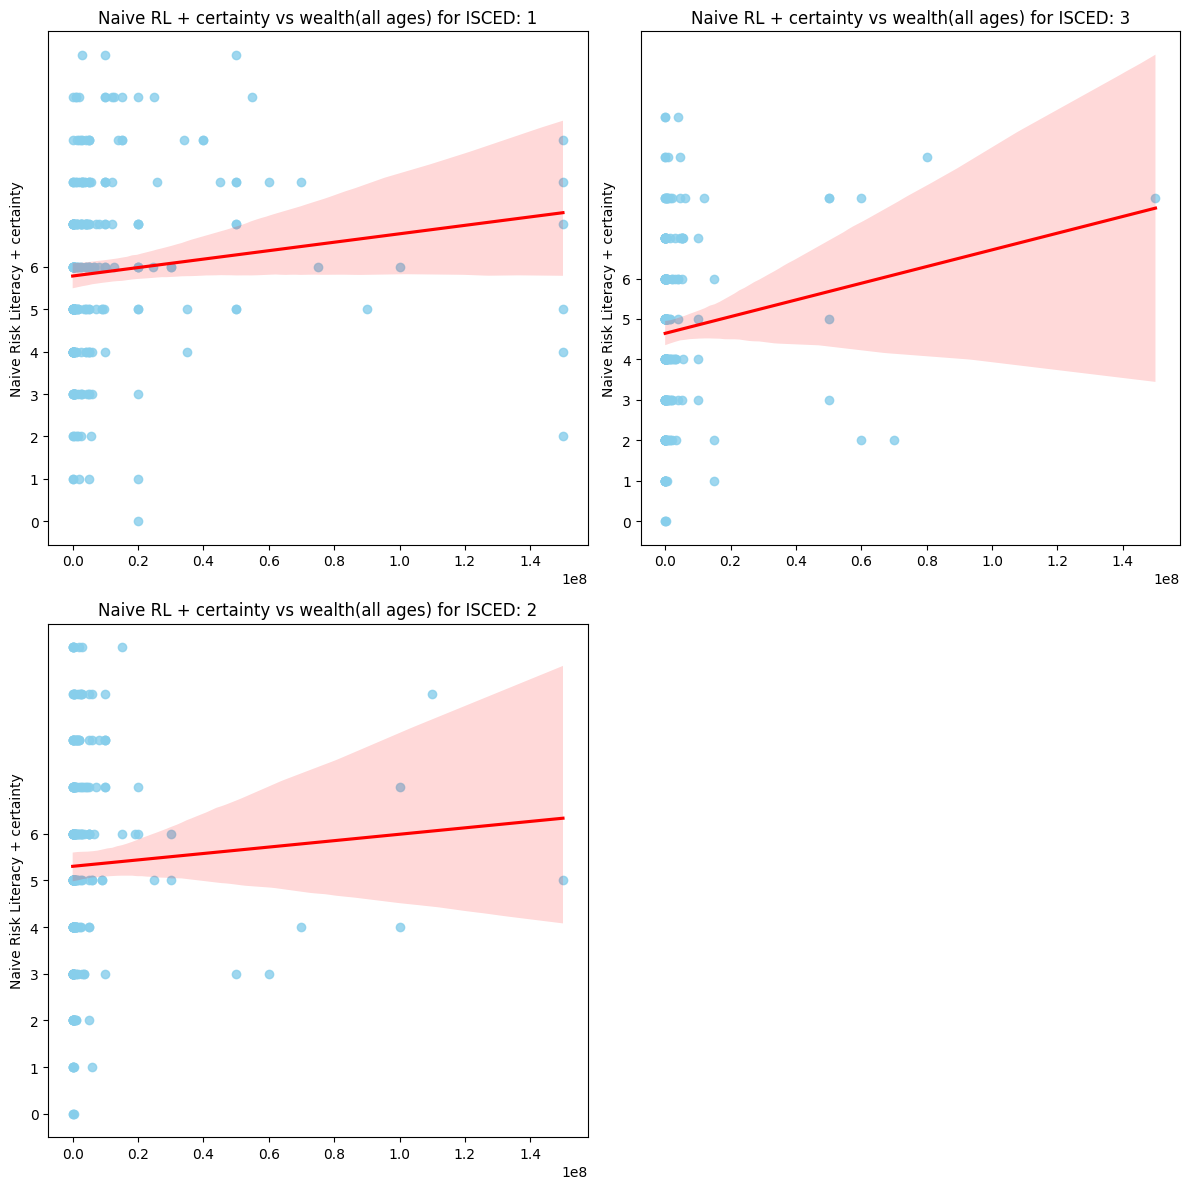

In [54]:
fig, axes = plt.subplots(2, 2, figsize = [12, 12])
axes = axes.flatten()

isced = ind_dyn2["isced"].unique()

for i, edu in enumerate(isced):
    sample = ind_dyn1.loc[(ind_dyn1["isced"] == edu) & (ind_dyn1["wealth"] != -1)].copy()
    x = sample["wealth"].values
    y = sample["Naive_RL_certainty_11"].values
    total = sample.sum() 
    
    sns.regplot(x=x, y=y, color="skyblue", ax = axes[i], line_kws={"color": "red"})

    axes[i].set_yticks(np.arange(0, 7, step = 1))
    
    axes[i].set_ylabel(f"Naive Risk Literacy + certainty")
    axes[i].set_title(f"Naive RL + certainty vs wealth(all ages) for ISCED: {edu}")


fig.delaxes(axes[i+1])
plt.tight_layout()
plt.show()

#### Show the relationship between sum of numeracy+graph literacy+certainty and income [31-59y] stratified by education

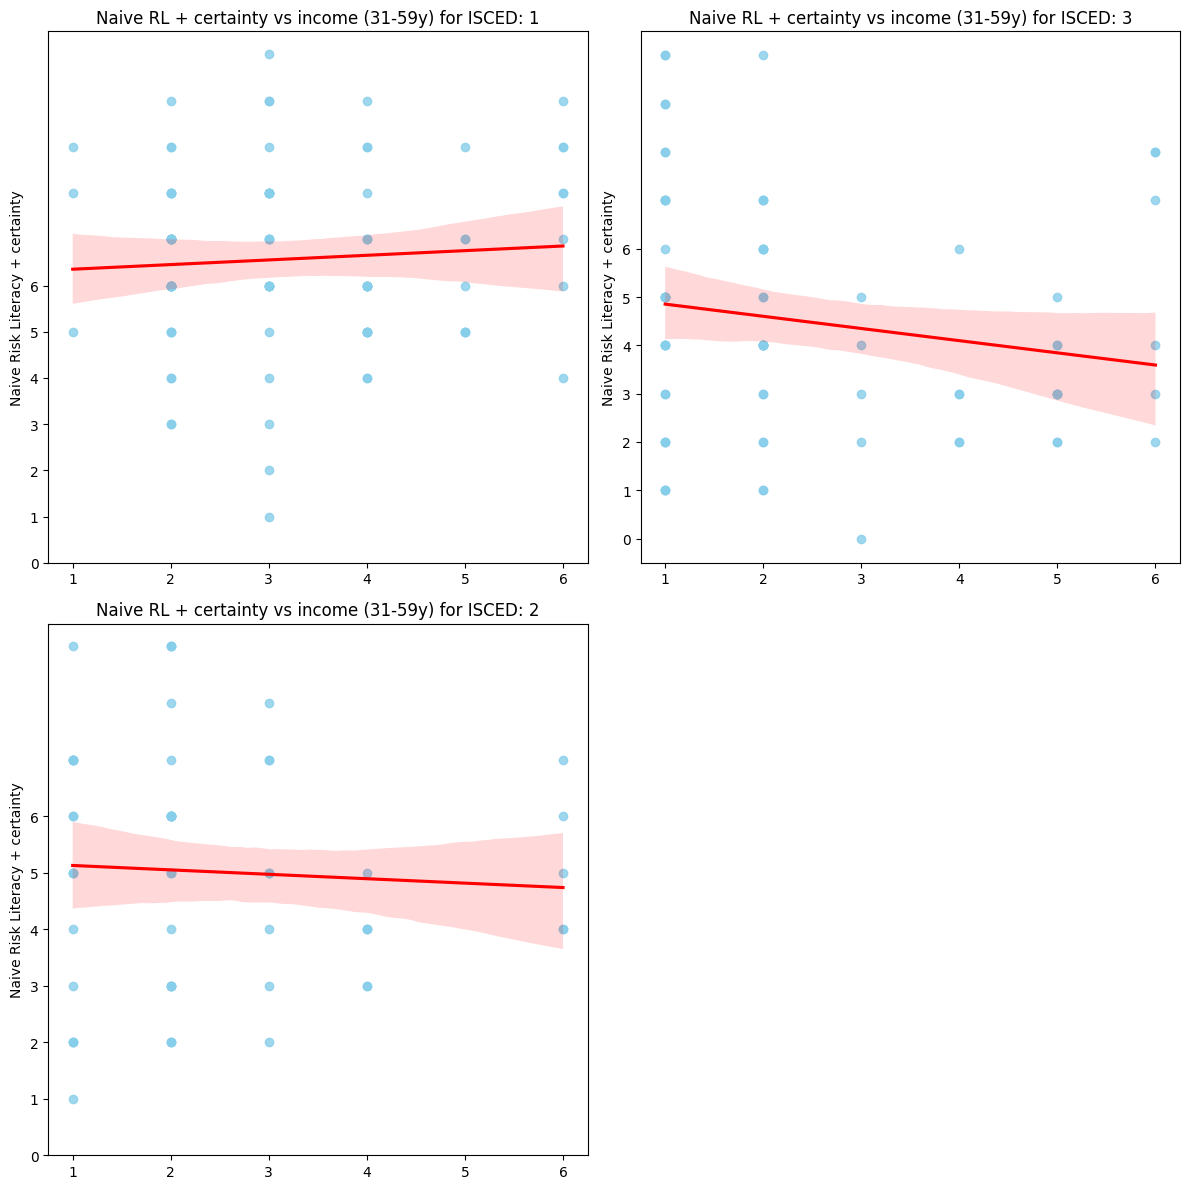

In [55]:
fig, axes = plt.subplots(2, 2, figsize = [12, 12])
axes = axes.flatten()

isced = ind_dyn2["isced"].unique()

for i, edu in enumerate(isced):
    sample = ind_dyn1.loc[
        (ind_dyn1["isced"] == edu)
        & (ind_dyn1["income"] != -1)
        & (ind_dyn1["age_rec"] == 3)].copy()
    
    x = sample["income"].values
    y = sample["Naive_RL_certainty_11"].values
    total = sample.sum() 
    
    sns.regplot(x=x, y=y, color="skyblue", ax = axes[i], line_kws={"color": "red"})

    axes[i].set_yticks(np.arange(0, 7, step = 1))
    
    axes[i].set_ylabel(f"Naive Risk Literacy + certainty")
    axes[i].set_title(f"Naive RL + certainty vs income (31-59y) for ISCED: {edu}")


fig.delaxes(axes[i+1])
plt.tight_layout()
plt.show()

### ii. Total literacy MEAN (=proportion correct of Numeracy, proportion correct of graph literacy, proportion of correct certainty)

#### Regressions

##### Predicting wealth: covariates(proxy to general intelligence), age (proxy to cohort), crt, financial literacy, Risk preference

In [56]:
data = ind_dyn2.loc[ind_dyn2["wealth"] != -1].copy()

model = sm.OLS(data["wealth"], sm.add_constant(
    data[["Naive_RL_certainty_%", "age_rec", "CRTScore_3", "FinancialLiteracy_3",
          "RiskAppetite_7"]]))

# Age group 2 = 18 to 35 y/o
# Age group 3 = 36 to 55 y/o
# Age group 4 = 56 to 75 y/o 

res = model.fit()
print(res.summary())

                            OLS Regression Results                            
Dep. Variable:                 wealth   R-squared:                       0.226
Model:                            OLS   Adj. R-squared:                  0.224
Method:                 Least Squares   F-statistic:                     92.59
Date:                Wed, 22 Oct 2025   Prob (F-statistic):           1.16e-85
Time:                        14:43:56   Log-Likelihood:                -6934.6
No. Observations:                1591   AIC:                         1.388e+04
Df Residuals:                    1585   BIC:                         1.391e+04
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                   61.4640 

##### Predicting wealth: income when analysing wealth

In [57]:
data = ind_dyn2.loc[
    (ind_dyn2["wealth"] != -1)
    & (ind_dyn2["income"] != -1)].copy()

model = sm.OLS(data["wealth"], sm.add_constant(data[[
    "Naive_RL_certainty_%", "age_rec", "CRTScore_3", "FinancialLiteracy_3",
    "RiskAppetite_7", "income"]]))

# Age group 2 = 18 to 35 y/o
# Age group 3 = 36 to 55 y/o
# Age group 4 = 56 to 75 y/o 

res = model.fit()
print(res.summary())

                            OLS Regression Results                            
Dep. Variable:                 wealth   R-squared:                       0.229
Model:                            OLS   Adj. R-squared:                  0.226
Method:                 Least Squares   F-statistic:                     76.92
Date:                Wed, 22 Oct 2025   Prob (F-statistic):           2.74e-84
Time:                        14:43:56   Log-Likelihood:                -6815.9
No. Observations:                1564   AIC:                         1.365e+04
Df Residuals:                    1557   BIC:                         1.368e+04
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                   61.1663 

##### Predicting income: covariates(proxy to general intelligence), age (proxy to cohort), crt, financial literacy, Risk preference

In [58]:
data = ind_dyn2.loc[ind_dyn2["income"] != -1].copy()

model = sm.OLS(data["income"], sm.add_constant(
    data[["Naive_RL_certainty_%", "age_rec","CRTScore_3", "FinancialLiteracy_3",
          "RiskAppetite_7"]]))

# Age group 2 = 18 to 35 y/o
# Age group 3 = 36 to 55 y/o
# Age group 4 = 56 to 75 y/o 

res = model.fit()
print(res.summary())

                            OLS Regression Results                            
Dep. Variable:                 income   R-squared:                       0.118
Model:                            OLS   Adj. R-squared:                  0.115
Method:                 Least Squares   F-statistic:                     41.61
Date:                Wed, 22 Oct 2025   Prob (F-statistic):           2.66e-40
Time:                        14:43:56   Log-Likelihood:                -2802.2
No. Observations:                1564   AIC:                             5616.
Df Residuals:                    1558   BIC:                             5649.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                    0.7132 

##### Predicting new outcomes: Response to crises (OLS)

##### Health

In [59]:
data = ind_dyn2.loc[ind_dyn2["wealth"] != -1].copy()

model = sm.OLS(data["health_crisis_score"], sm.add_constant(
    data[["Naive_RL_certainty_%", "age_rec","CRTScore_3", "FinancialLiteracy_3",
          "RiskAppetite_7", "wealth"]]))

# Age group 2 = 18 to 35 y/o
# Age group 3 = 36 to 55 y/o
# Age group 4 = 56 to 75 y/o 

res = model.fit()
print(res.summary())

                             OLS Regression Results                            
Dep. Variable:     health_crisis_score   R-squared:                       0.079
Model:                             OLS   Adj. R-squared:                  0.075
Method:                  Least Squares   F-statistic:                     22.62
Date:                 Wed, 22 Oct 2025   Prob (F-statistic):           1.07e-25
Time:                         14:43:56   Log-Likelihood:                -1076.8
No. Observations:                 1591   AIC:                             2168.
Df Residuals:                     1584   BIC:                             2205.
Df Model:                            6                                         
Covariance Type:             nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                 

##### Finance

In [60]:
data = ind_dyn2.loc[ind_dyn2["wealth"] != -1].copy()

model = sm.OLS(data["finance_crisis_score"], sm.add_constant(
    data[["Naive_RL_certainty_%", "age_rec","CRTScore_3", "FinancialLiteracy_3",
          "RiskAppetite_7", "wealth"]]))

# Age group 2 = 18 to 35 y/o
# Age group 3 = 36 to 55 y/o
# Age group 4 = 56 to 75 y/o 

res = model.fit()
print(res.summary())

                             OLS Regression Results                             
Dep. Variable:     finance_crisis_score   R-squared:                       0.085
Model:                              OLS   Adj. R-squared:                  0.082
Method:                   Least Squares   F-statistic:                     24.64
Date:                  Wed, 22 Oct 2025   Prob (F-statistic):           4.85e-28
Time:                          14:43:56   Log-Likelihood:                -1077.3
No. Observations:                  1591   AIC:                             2169.
Df Residuals:                      1584   BIC:                             2206.
Df Model:                             6                                         
Covariance Type:              nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
const       

##### Digital

In [61]:
data = ind_dyn2.loc[ind_dyn2["wealth"] != -1].copy()

model = sm.OLS(data["digital_crisis_score"], sm.add_constant(
    data[["Naive_RL_certainty_%", "age_rec","CRTScore_3", "FinancialLiteracy_3",
          "RiskAppetite_7", "wealth"]]))

# Age group 2 = 18 to 35 y/o
# Age group 3 = 36 to 55 y/o
# Age group 4 = 56 to 75 y/o 

res = model.fit()
print(res.summary())

                             OLS Regression Results                             
Dep. Variable:     digital_crisis_score   R-squared:                       0.047
Model:                              OLS   Adj. R-squared:                  0.043
Method:                   Least Squares   F-statistic:                     13.03
Date:                  Wed, 22 Oct 2025   Prob (F-statistic):           1.99e-14
Time:                          14:43:56   Log-Likelihood:                -1116.3
No. Observations:                  1591   AIC:                             2247.
Df Residuals:                      1584   BIC:                             2284.
Df Model:                             6                                         
Covariance Type:              nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
const       

##### Social

In [62]:
data = ind_dyn2.loc[ind_dyn2["wealth"] != -1].copy()

model = sm.OLS(data["social_crisis_score"], sm.add_constant(
    data[["Naive_RL_certainty_%", "age_rec","CRTScore_3", "FinancialLiteracy_3",
          "RiskAppetite_7", "wealth"]]))

# Age group 2 = 18 to 35 y/o
# Age group 3 = 36 to 55 y/o
# Age group 4 = 56 to 75 y/o 

res = model.fit()
print(res.summary())

                             OLS Regression Results                            
Dep. Variable:     social_crisis_score   R-squared:                       0.048
Model:                             OLS   Adj. R-squared:                  0.044
Method:                  Least Squares   F-statistic:                     13.20
Date:                 Wed, 22 Oct 2025   Prob (F-statistic):           1.24e-14
Time:                         14:43:56   Log-Likelihood:                -1106.2
No. Observations:                 1591   AIC:                             2226.
Df Residuals:                     1584   BIC:                             2264.
Df Model:                            6                                         
Covariance Type:             nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                 

##### Total

In [63]:
data = ind_dyn2.loc[ind_dyn2["wealth"] != -1].copy()

model = sm.OLS(data["total_crisis_score"], sm.add_constant(
    data[["Naive_RL_certainty_%", "age_rec","CRTScore_3", "FinancialLiteracy_3",
          "RiskAppetite_7", "wealth"]]))

# Age group 2 = 18 to 35 y/o
# Age group 3 = 36 to 55 y/o
# Age group 4 = 56 to 75 y/o 

res = model.fit()
print(res.summary())

                            OLS Regression Results                            
Dep. Variable:     total_crisis_score   R-squared:                       0.155
Model:                            OLS   Adj. R-squared:                  0.152
Method:                 Least Squares   F-statistic:                     48.50
Date:                Wed, 22 Oct 2025   Prob (F-statistic):           7.44e-55
Time:                        14:43:56   Log-Likelihood:                -2467.4
No. Observations:                1591   AIC:                             4949.
Df Residuals:                    1584   BIC:                             4986.
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                    2.0950 

##### QOLS (total sum): OLS

In [64]:
data = ind_dyn2.loc[ind_dyn2["wealth"] != -1].copy()

model = sm.OLS(data["QOL_score"], sm.add_constant(
    data[["Naive_RL_certainty_%", "age_rec","CRTScore_3", "FinancialLiteracy_3",
          "RiskAppetite_7", "wealth"]]))

# Age group 2 = 18 to 35 y/o
# Age group 3 = 36 to 55 y/o
# Age group 4 = 56 to 75 y/o 

res = model.fit()
print(res.summary())

                            OLS Regression Results                            
Dep. Variable:              QOL_score   R-squared:                       0.078
Model:                            OLS   Adj. R-squared:                  0.074
Method:                 Least Squares   F-statistic:                     22.19
Date:                Wed, 22 Oct 2025   Prob (F-statistic):           3.37e-25
Time:                        14:43:56   Log-Likelihood:                -5006.2
No. Observations:                1591   AIC:                         1.003e+04
Df Residuals:                    1584   BIC:                         1.006e+04
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                   27.5675 

##### QOLS (one at a time): Ordered Model

In [65]:
# IMPORTANT: Please check the dependent variable in each output
data = ind_dyn2.loc[ind_dyn2["wealth"] != -1].copy()

for num in range(1, 9):
    print(f"!!! QOL {num} !!!")
    qol_col = f"QOL{num}"
    data[qol_col] = pd.Categorical(data[qol_col], ordered=True)

    model = OrderedModel(data[qol_col], 
                         data[["Naive_RL_certainty_%", "age_rec","CRTScore_3",
                               "FinancialLiteracy_3", "RiskAppetite_7", "wealth"]],
                               distr='logit')

    # Age group 2 = 18 to 35 y/o
    # Age group 3 = 36 to 55 y/o
    # Age group 4 = 56 to 75 y/o 

    res = model.fit(method='bfgs')
    print(res.summary())
    print("\n")

!!! QOL 1 !!!


Optimization terminated successfully.
         Current function value: 1.176315
         Iterations: 29
         Function evaluations: 33
         Gradient evaluations: 33
                             OrderedModel Results                             
Dep. Variable:                   QOL1   Log-Likelihood:                -1871.5
Model:                   OrderedModel   AIC:                             3763.
Method:            Maximum Likelihood   BIC:                             3817.
Date:                Wed, 22 Oct 2025                                         
Time:                        14:43:57                                         
No. Observations:                1591                                         
Df Residuals:                    1581                                         
Df Model:                           6                                         
                           coef    std err          z      P>|z|      [0.025      0.975]
----------------------------

# OUTPUT DATASET

In [66]:
euro.to_csv("221025_RL_EUR_scored.csv")
ind_dyn1.to_csv("221025_RL_IND_dyn1_scored.csv")
ind_dyn2.to_csv("221025_RL_IND_dyn2_scored.csv")